# Skeletonization & Skeleton-Based Phenotyping (Ribes_04)

This notebook takes the segmented 3D reconstruction (point cloud + semantic + instance labels)
and focuses on **robust skeletonization** of the plant structure:

1. **L1-median skeleton extraction** per segmented organ (leaf/stem instance), with an
   adaptive neighborhood radius and outlier-resistant weighting (not a fixed-bandwidth,
   single-pass median — it iterates to convergence and re-estimates local density each step).
2. **Skeleton graph construction**: a k-NN graph reduced to a minimum-spanning-tree, then
   pruned of statistically anomalous ("bridging") edges so noise/occlusion gaps don't create
   fake long branches.
3. **Skeleton-derived traits**: total/per-organ path length, node degree, branch points,
   endpoints (tips).
4. **Color-based phenotypic traits**: ExG / ExR / ExGR / GLI / VARI / NGRDI vegetation
   indices, vegetation fraction, and a data-adaptive (not just fixed-threshold) health
   classification.
5. Publication-quality figures (300 dpi) and CSV/JSON tables, all saved to Google Drive.

**Input (Google Drive):**
```
segmentation_jetcobot_internship/gt_reconstruction/
├── Ribes_04.ply
├── Ribes_04_Confidence.txt
├── Ribes_04_InstanceLabels.txt
└── Ribes_04_SemanticLabels.txt
```

**Output (Google Drive):**
```
segmentation_jetcobot_internship/outputs/pheno_skeleton/
├── figures/            (PNG, 300 dpi)
├── metrics/             (CSV + JSON tables)
├── skeleton/            (raw skeleton nodes/edges, .npz, reusable)
└── pheno_skeleton_report.json
```

> This notebook is designed to be robust to a real segmentation pipeline: instances that are
> too small to skeletonize are skipped (not crashed on), isolated points fall back to a
> wider search radius, and long spurious MST edges are pruned automatically. Every tunable
> lives in the **Configuration** cell below.


## 1. Setup — install & import libraries

In [1]:
!pip install -q open3d plyfile scipy pandas matplotlib seaborn networkx

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 127.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.1/140.1 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.3/217.3 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 98.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 127.7 MB/s eta 0:00:00


In [2]:
import os, json, time, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import ListedColormap
from matplotlib.collections import LineCollection
import seaborn as sns
from scipy.spatial import ConvexHull, cKDTree
import networkx as nx

import open3d as o3d

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["font.family"] = "DejaVu Sans"

RNG = np.random.default_rng(0)

print("open3d:", o3d.__version__, "| networkx:", nx.__version__)

open3d: 0.19.0 | networkx: 3.6.1


## 2. Mount Google Drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 3. Configuration

Edit these if your setup differs. Everything the skeletonizer needs is tunable here — no magic numbers buried later in the notebook.

In [4]:
# ---------------- PATHS ----------------
DRIVE_ROOT   = "/content/drive/MyDrive/segmentation_jetcobot_internship"
GT_DIR       = os.path.join(DRIVE_ROOT, "gt_reconstruction")
OUT_DIR      = os.path.join(DRIVE_ROOT, "outputs", "pheno_skeleton")
FIG_DIR      = os.path.join(OUT_DIR, "figures")
METRICS_DIR  = os.path.join(OUT_DIR, "metrics")
SKEL_DIR     = os.path.join(OUT_DIR, "skeleton")

for d in (FIG_DIR, METRICS_DIR, SKEL_DIR):
    os.makedirs(d, exist_ok=True)

SAMPLE_NAME  = "Ribes_04"
PLY_PATH        = os.path.join(GT_DIR, f"{SAMPLE_NAME}.ply")
SEMANTIC_PATH   = os.path.join(GT_DIR, f"{SAMPLE_NAME}_SemanticLabels.txt")
INSTANCE_PATH   = os.path.join(GT_DIR, f"{SAMPLE_NAME}_InstanceLabels.txt")
CONFIDENCE_PATH = os.path.join(GT_DIR, f"{SAMPLE_NAME}_Confidence.txt")

# Which axis points "up" (plant height axis): 'x', 'y', or 'z'
AXIS_UP = "z"

# Label id treated as background / unlabeled (excluded from per-instance skeletonization)
BACKGROUND_INSTANCE_LABEL = 0
BACKGROUND_SEMANTIC_LABEL = 0

# Display / plotting
MAX_DISPLAY_POINTS = 60_000   # subsample for scatter plots (keeps figures fast + light)

# ---------------- SKELETONIZATION ----------------
MIN_POINTS_FOR_SKELETON = 30     # instances smaller than this are skipped (too little info)
SKELETON_POINTS_PER_1K  = 6      # target skeleton nodes per 1000 organ points
MIN_SKELETON_NODES      = 6
MAX_SKELETON_NODES      = 200

RADIUS_KNN_K       = 8    # neighbors used to estimate local point spacing -> adaptive radius
RADIUS_FACTOR       = 2.2  # radius = RADIUS_FACTOR * median local spacing
L1_MAX_ITER          = 40
L1_TOL               = 1e-5      # stop contraction early once movement < tol * radius
L1_REPULSION_WEIGHT   = 0.35      # sparsity/repulsion term, keeps skeleton nodes from collapsing

GRAPH_KNN_K          = 6         # neighbors considered when building the candidate skeleton graph
EDGE_PRUNE_MAD_FACTOR = 3.0       # prune MST edges longer than median + factor * MAD (outlier bridges)

# ---------------- HEALTH / VEGETATION INDICES ----------------
# Fixed thresholds are used first; if they yield a degenerate split (e.g. >95% in one
# category) we fall back to data-driven quantile thresholds on VARI/NGRDI for robustness.
VARI_HEALTHY_T, NGRDI_HEALTHY_T   = 0.15, 0.10
VARI_MODERATE_T, NGRDI_MODERATE_T = 0.05, 0.02
VARI_STRESSED_T                     = -0.05

print("Config OK. Outputs will be written under:", OUT_DIR)

Config OK. Outputs will be written under: /content/drive/MyDrive/segmentation_jetcobot_internship/outputs/pheno_skeleton


## 4. Load point cloud + labels

Robust loader: handles label files that are single-column, whitespace-, or comma-separated, and validates row counts against the point cloud.

In [5]:
def load_label_file(path, n_expected=None, dtype=float):
    """Load a per-point label/confidence .txt file, robust to delimiter differences."""
    arr = np.loadtxt(path, delimiter=None)
    arr = np.atleast_1d(arr).astype(dtype)
    if arr.ndim > 1:
        arr = arr[:, -1]  # if multiple columns, assume label is the LAST column
    if n_expected is not None and len(arr) != n_expected:
        raise ValueError(f"{path}: got {len(arr)} rows, expected {n_expected}")
    return arr

pcd = o3d.io.read_point_cloud(PLY_PATH)
points = np.asarray(pcd.points)
n_points = points.shape[0]
has_colors = pcd.has_colors()
colors = np.asarray(pcd.colors) if has_colors else None  # in [0,1]

semantic   = load_label_file(SEMANTIC_PATH, n_points, dtype=int)
instance   = load_label_file(INSTANCE_PATH, n_points, dtype=int)
confidence = load_label_file(CONFIDENCE_PATH, n_points, dtype=float) if os.path.exists(CONFIDENCE_PATH) else np.ones(n_points)

sem_classes = sorted(np.unique(semantic).tolist())
inst_ids_all = sorted(np.unique(instance).tolist())
inst_ids = [i for i in inst_ids_all if i != BACKGROUND_INSTANCE_LABEL]
n_inst = len(inst_ids)

axis_map = {"x": 0, "y": 1, "z": 2}
up_idx = axis_map[AXIS_UP]
other_idx = [i for i in range(3) if i != up_idx]

print(f"Loaded {n_points:,} points | has_colors={has_colors}")
print(f"Semantic classes: {sem_classes}")
print(f"Instances (excl. background): {n_inst}")

Loaded 1,190,366 points | has_colors=True
Semantic classes: [1, 2]
Instances (excl. background): 33


## 5. L1-Median Skeletonization

For a set of candidate skeleton points $\{\mathbf{s}_k\}$, each is refined toward the
**weighted L1 median** (geometric median, robust to outliers) of its local point
neighborhood $\mathcal{N}_k$:

$$\mathbf{s}_k^{*} = \underset{\mathbf{s}\in\mathbb{R}^3}{\operatorname{arg\,min}} \sum_{\mathbf{x}_i\in\mathcal{N}_k} w_i \lVert \mathbf{x}_i - \mathbf{s} \rVert_2$$

solved iteratively (Weiszfeld's algorithm) rather than in closed form, since the L1 median
has no closed-form solution in $\mathbb{R}^3$.

**Robustness choices beyond a plain single-pass local median:**
- The neighborhood radius is **adaptive per-instance** (derived from local point spacing),
  not a single fixed value for the whole plant — thin stems and broad leaves get an
  appropriately sized neighborhood.
- Weights $w_i$ are a Gaussian kernel of distance, so distant/outlier points barely
  influence the estimate (an L1 median is already robust to outliers; the kernel makes it
  *local* as well).
- A small **repulsion term** between neighboring skeleton candidates discourages them from
  collapsing onto a single point, which keeps the candidate set spread along the organ
  instead of degenerating to one blob.
- Isolated candidates (empty neighborhood, e.g. at a thin leaf tip) fall back to a widened
  k-NN search instead of stalling.


In [6]:
def farthest_point_sampling(pts, n_samples, seed=0):
    """Greedy farthest-point sampling — spreads skeleton candidates along the organ's extent
    instead of a plain random draw, which is what plain random draws systematically miss (thin
    tips / sparse ends of an organ)."""
    n = len(pts)
    if n_samples >= n:
        return np.arange(n)
    rng = np.random.default_rng(seed)
    chosen = [rng.integers(0, n)]
    dist = np.linalg.norm(pts - pts[chosen[0]], axis=1)
    for _ in range(n_samples - 1):
        idx = int(np.argmax(dist))
        chosen.append(idx)
        dist = np.minimum(dist, np.linalg.norm(pts - pts[idx], axis=1))
    return np.array(chosen)


def adaptive_radius(pts, k=RADIUS_KNN_K, factor=RADIUS_FACTOR):
    """Local point spacing (median k-NN distance) scaled by `factor` -> neighborhood radius.
    Adapts to point density instead of using one fixed radius for the whole plant."""
    tree = cKDTree(pts)
    k_eff = min(k + 1, len(pts))
    d, _ = tree.query(pts, k=k_eff)
    spacing = np.median(d[:, 1:]) if k_eff > 1 else np.median(d)
    return max(factor * spacing, 1e-6)


def l1_median_skeleton(pts, n_target, radius, max_iter=L1_MAX_ITER, tol=L1_TOL,
                        repulsion=L1_REPULSION_WEIGHT, seed=0):
    """Iterative weighted-L1-median contraction of `pts` onto `n_target` skeleton points."""
    seed_idx = farthest_point_sampling(pts, n_target, seed=seed)
    S = pts[seed_idx].astype(float).copy()
    tree = cKDTree(pts)
    h = radius

    for it in range(max_iter):
        S_prev = S.copy()
        S_tree = cKDTree(S)
        S_new = np.empty_like(S)

        for i, s in enumerate(S):
            idx = tree.query_ball_point(s, r=h)
            if len(idx) == 0:
                _, idx = tree.query(s, k=min(10, len(pts)))
                idx = np.atleast_1d(idx)
            nbrs = pts[idx]
            d = np.linalg.norm(nbrs - s, axis=1) + 1e-9
            w = np.exp(-(d ** 2) / ((h / 2.0) ** 2 + 1e-9))
            num = (nbrs / d[:, None] * w[:, None]).sum(axis=0)
            den = (w / d).sum() + 1e-9
            s_med = num / den

            # sparsity / repulsion vs. nearby skeleton candidates -> prevents collapse
            r_idx = S_tree.query_ball_point(s, r=h)
            r_idx = [j for j in r_idx if j != i]
            if r_idx:
                rep = (s - S[r_idx])
                r_d = np.linalg.norm(rep, axis=1)[:, None] + 1e-9
                rep_vec = (rep / r_d).mean(axis=0)
            else:
                rep_vec = np.zeros(3)

            S_new[i] = (1 - repulsion) * s_med + repulsion * (s + 0.5 * h * rep_vec)

        S = S_new
        shift = np.linalg.norm(S - S_prev, axis=1).mean()
        if shift < tol * h:
            break

    return S


print("Skeletonization functions ready.")

Skeletonization functions ready.


## 6. Skeleton graph construction

Candidate skeleton points are connected with a k-NN graph, reduced to a **minimum spanning tree** (guarantees a connected, acyclic skeleton with no redundant loops), then pruned of edges that are statistical outliers in length — these are almost always spurious "bridges" created by occlusion gaps or noise, not real plant structure.

In [7]:
def build_skeleton_graph(skel_pts, k=GRAPH_KNN_K, prune_factor=EDGE_PRUNE_MAD_FACTOR):
    n = len(skel_pts)
    G = nx.Graph()
    for i, p in enumerate(skel_pts):
        G.add_node(i, pos=p)
    if n < 2:
        return G

    tree = cKDTree(skel_pts)
    k_eff = min(k + 1, n)
    d, idx = tree.query(skel_pts, k=k_eff)
    for i in range(n):
        for j, dist in zip(np.atleast_1d(idx[i])[1:], np.atleast_1d(d[i])[1:]):
            G.add_edge(i, int(j), weight=float(dist))

    if G.number_of_edges() == 0:
        return G

    mst = nx.minimum_spanning_tree(G, weight="weight")

    weights = np.array([data["weight"] for _, _, data in mst.edges(data=True)])
    if len(weights) >= 3:
        med = np.median(weights)
        mad = np.median(np.abs(weights - med)) + 1e-9
        thresh = med + prune_factor * mad
        bad_edges = [(u, v) for u, v, data in mst.edges(data=True) if data["weight"] > thresh]
        mst.remove_edges_from(bad_edges)

    return mst


def graph_metrics(G):
    """Structural traits from a skeleton graph: path length, degree distribution, tips/branches."""
    if G.number_of_nodes() == 0:
        return dict(n_nodes=0, n_edges=0, total_length=0.0, n_endpoints=0,
                    n_branch_points=0, mean_degree=0.0)
    total_length = sum(data["weight"] for _, _, data in G.edges(data=True))
    degrees = dict(G.degree())
    n_endpoints = sum(1 for d in degrees.values() if d == 1)
    n_branch_points = sum(1 for d in degrees.values() if d >= 3)
    mean_degree = float(np.mean(list(degrees.values()))) if degrees else 0.0
    return dict(n_nodes=G.number_of_nodes(), n_edges=G.number_of_edges(),
                total_length=float(total_length), n_endpoints=int(n_endpoints),
                n_branch_points=int(n_branch_points), mean_degree=mean_degree)

print("Graph-building functions ready.")

Graph-building functions ready.


## 7. Run skeletonization per instance (organ) + assemble the global plant skeleton

Each segmented instance (leaf/stem) is skeletonized independently — this keeps the local density estimate honest (a leaf and a distant stem shouldn't influence each other's neighborhood radius). All per-organ skeleton points are then pooled and re-connected into a single global graph, so organs that are spatially close (e.g. a leaf attached to a stem) end up linked in the final plant-level skeleton.

In [8]:
t0 = time.time()
instance_skeletons = {}   # instance_id -> (skeleton points array, local graph)
skel_rows = []

for iid in inst_ids:
    mask = instance == iid
    n = int(mask.sum())
    if n < MIN_POINTS_FOR_SKELETON:
        skel_rows.append(dict(instance_id=int(iid), n_points=n, skeletonized=False,
                               reason="too few points"))
        continue

    pts_i = points[mask]
    sem_majority = int(pd.Series(semantic[mask]).mode().iloc[0])

    n_target = int(np.clip(n / 1000 * SKELETON_POINTS_PER_1K, MIN_SKELETON_NODES, MAX_SKELETON_NODES))
    radius = adaptive_radius(pts_i)

    try:
        S = l1_median_skeleton(pts_i, n_target, radius, seed=int(iid))
        G_local = build_skeleton_graph(S)
        m = graph_metrics(G_local)
        instance_skeletons[iid] = (S, G_local)
        skel_rows.append(dict(instance_id=int(iid), semantic_class_majority=sem_majority,
                               n_points=n, skeletonized=True, radius_used=float(radius),
                               **m))
    except Exception as e:
        skel_rows.append(dict(instance_id=int(iid), n_points=n, skeletonized=False,
                               reason=str(e)))

df_skel_instance = pd.DataFrame(skel_rows)
print(f"Skeletonized {sum(1 for r in skel_rows if r.get('skeletonized')):d}/{len(inst_ids)} instances "
      f"in {time.time()-t0:.1f}s")
df_skel_instance.head(10)

Skeletonized 33/33 instances in 14.0s


,instance_id,semantic_class_majority,n_points,skeletonized,radius_used,n_nodes,n_edges,total_length,n_endpoints,n_branch_points,mean_degree
0,1,1,174696,True,0.068688,200,161,146.473269,65,31,1.610000
1,2,2,49103,True,0.067841,200,190,72.304495,69,54,1.900000
2,3,2,38270,True,0.067372,200,189,61.372083,76,53,1.890000
3,4,2,69528,True,0.067372,200,192,80.927557,70,49,1.920000
4,5,2,44761,True,0.068688,200,186,69.672552,70,51,1.860000
5,6,2,18615,True,0.070800,111,100,33.063788,37,26,1.801802
6,7,2,41069,True,0.071690,200,183,65.695913,67,51,1.830000
7,8,2,74112,True,0.070005,200,188,85.906676,67,49,1.880000
8,9,2,47792,True,0.070826,200,185,71.086800,73,56,1.850000
9,10,2,57937,True,0.069979,200,187,76.239397,65,54,1.870000


In [9]:
# --- assemble the global plant skeleton from all per-instance skeleton points ---
all_S = []
all_owner = []  # which instance each skeleton point came from
for iid, (S, _) in instance_skeletons.items():
    all_S.append(S)
    all_owner.extend([iid] * len(S))

if all_S:
    global_S = np.vstack(all_S)
    global_owner = np.array(all_owner)
    global_G = build_skeleton_graph(global_S)
    global_metrics_skel = graph_metrics(global_G)
else:
    global_S = np.zeros((0, 3))
    global_owner = np.zeros((0,), dtype=int)
    global_G = nx.Graph()
    global_metrics_skel = graph_metrics(global_G)

print("Global skeleton:", global_metrics_skel)

np.savez(os.path.join(SKEL_DIR, f"{SAMPLE_NAME}_skeleton.npz"),
         nodes=global_S, owner_instance=global_owner,
         edges=np.array(list(global_G.edges())))
print("Saved raw skeleton (nodes/edges) to", os.path.join(SKEL_DIR, f"{SAMPLE_NAME}_skeleton.npz"))

Global skeleton: {'n_nodes': 4604, 'n_edges': 4284, 'total_length': 1555.3399566913315, 'n_endpoints': 1591, 'n_branch_points': 1208, 'mean_degree': 1.8609904430929627}
Saved raw skeleton (nodes/edges) to /content/drive/MyDrive/segmentation_jetcobot_internship/outputs/pheno_skeleton/skeleton/Ribes_04_skeleton.npz


## 8. Skeleton structural metrics table

In [10]:
skel_csv_path = os.path.join(METRICS_DIR, "skeleton_instance_metrics.csv")
df_skel_instance.to_csv(skel_csv_path, index=False)

global_skeleton_summary = {
    "sample_name": SAMPLE_NAME,
    "n_instances_total": int(n_inst),
    "n_instances_skeletonized": int(sum(1 for r in skel_rows if r.get("skeletonized"))),
    **global_metrics_skel,
}
with open(os.path.join(METRICS_DIR, "skeleton_global_summary.json"), "w") as f:
    json.dump(global_skeleton_summary, f, indent=2)

print("Global skeleton summary:")
for k, v in global_skeleton_summary.items():
    print(f"  {k}: {v}")
print("\nSaved:", skel_csv_path)

Global skeleton summary:
  sample_name: Ribes_04
  n_instances_total: 33
  n_instances_skeletonized: 33
  n_nodes: 4604
  n_edges: 4284
  total_length: 1555.3399566913315
  n_endpoints: 1591
  n_branch_points: 1208
  mean_degree: 1.8609904430929627

Saved: /content/drive/MyDrive/segmentation_jetcobot_internship/outputs/pheno_skeleton/metrics/skeleton_instance_metrics.csv


## 9. Skeleton visualization

Three orthogonal views (front / side / top) of the point cloud with the fused plant skeleton overlaid, plus a graph-only panel colored by node degree (tips vs. branch points) — this is the figure that plays the role of `img/11.png` in the report.

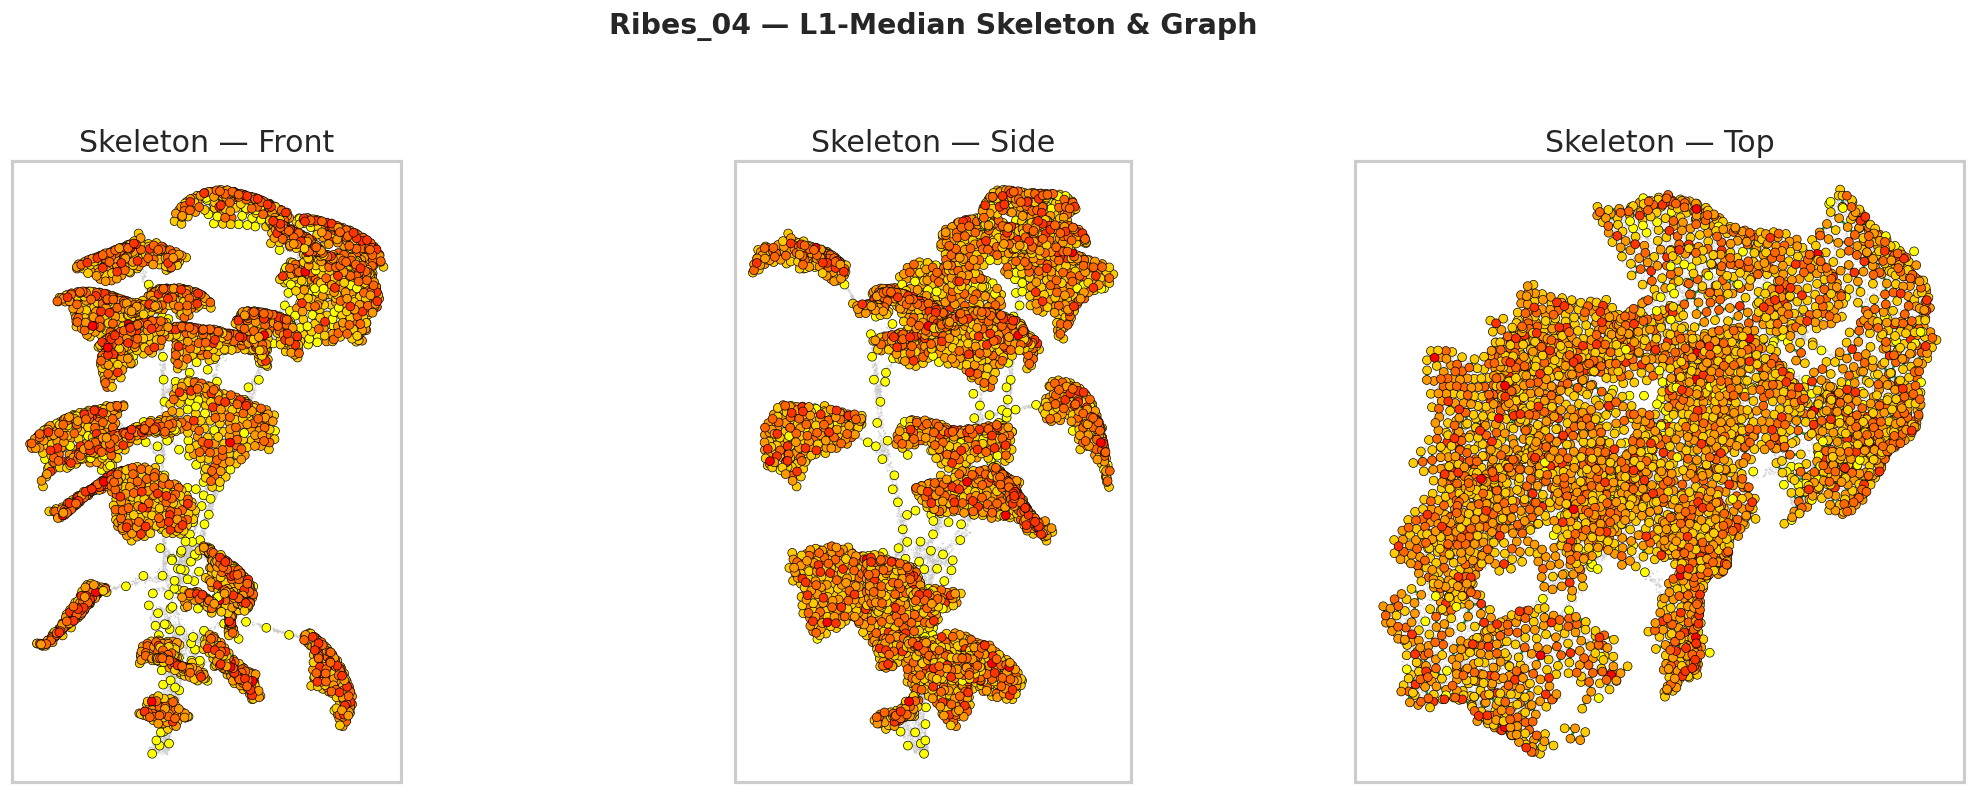

In [11]:
def subsample_idx(n, cap=MAX_DISPLAY_POINTS, seed=0):
    if n <= cap:
        return np.arange(n)
    rng = np.random.default_rng(seed)
    return rng.choice(n, size=cap, replace=False)

disp_idx = subsample_idx(n_points)
P = points[disp_idx]

view_defs = [("Front", other_idx[0], up_idx), ("Side", other_idx[1], up_idx), ("Top", other_idx[0], other_idx[1])]

fig, axes = plt.subplots(1, 3, figsize=(19, 6.5))
for ax, (name, ix, iy) in zip(axes, view_defs):
    ax.scatter(P[:, ix], P[:, iy], c="#c9c9c9", s=1.0, linewidths=0, alpha=0.6, zorder=1)
    if global_G.number_of_edges() > 0:
        segs = [ [global_S[u][[ix, iy]], global_S[v][[ix, iy]]] for u, v in global_G.edges() ]
        ax.add_collection(LineCollection(segs, colors="#1a9850", linewidths=1.6, zorder=2))
    degs = dict(global_G.degree())
    node_deg = np.array([degs.get(i, 0) for i in range(len(global_S))])
    if len(global_S):
        ax.scatter(global_S[:, ix], global_S[:, iy], c=node_deg, cmap="autumn_r", s=28,
                   edgecolors="black", linewidths=0.4, zorder=3)
    ax.set_title(f"Skeleton — {name}")
    ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([])

fig.suptitle(f"{SAMPLE_NAME} — L1-Median Skeleton & Graph", y=1.03, fontsize=17, fontweight="bold")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "11_skeleton_graph.png"), bbox_inches="tight")
plt.show()

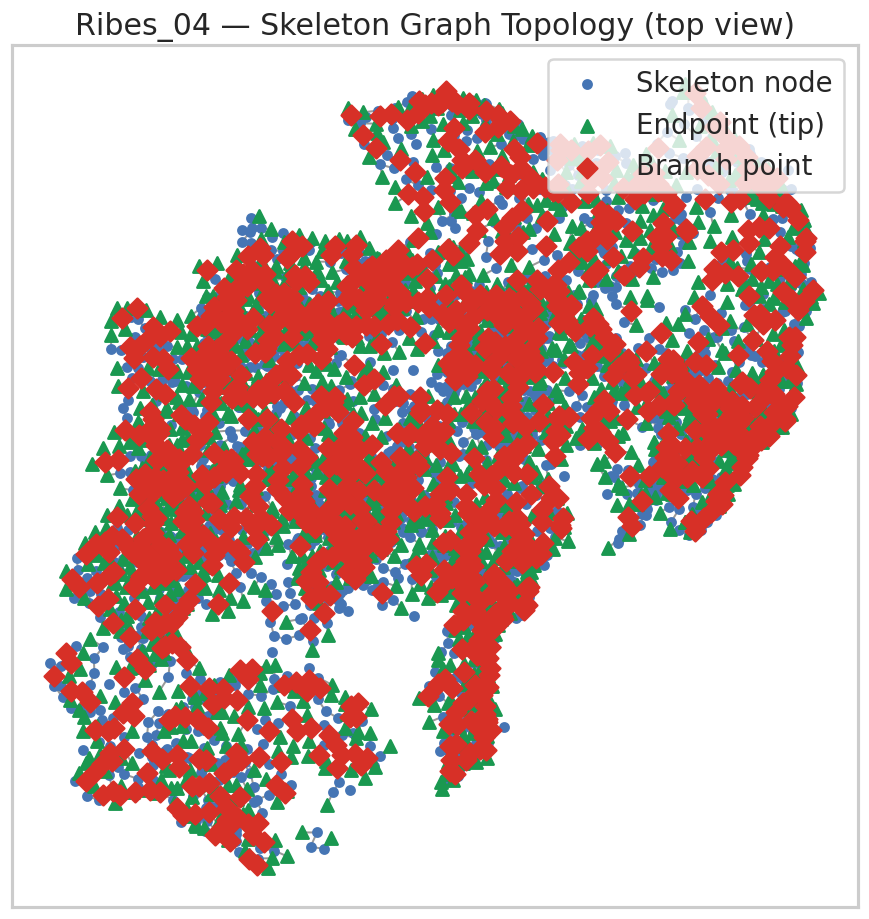

In [12]:
# --- graph-only panel: degree-colored nodes, endpoints vs branch points highlighted ---
fig, ax = plt.subplots(figsize=(8, 8))
ix, iy = other_idx[0], other_idx[1]  # top view
if global_G.number_of_edges() > 0:
    segs = [ [global_S[u][[ix, iy]], global_S[v][[ix, iy]]] for u, v in global_G.edges() ]
    ax.add_collection(LineCollection(segs, colors="#999999", linewidths=1.2, zorder=1))

degs = dict(global_G.degree())
node_deg = np.array([degs.get(i, 0) for i in range(len(global_S))]) if len(global_S) else np.array([])
if len(global_S):
    tip_mask = node_deg == 1
    branch_mask = node_deg >= 3
    mid_mask = ~tip_mask & ~branch_mask
    ax.scatter(global_S[mid_mask, ix], global_S[mid_mask, iy], c="#4575b4", s=25, label="Skeleton node", zorder=2)
    ax.scatter(global_S[tip_mask, ix], global_S[tip_mask, iy], c="#1a9850", s=55, marker="^", label="Endpoint (tip)", zorder=3)
    ax.scatter(global_S[branch_mask, ix], global_S[branch_mask, iy], c="#d73027", s=70, marker="D", label="Branch point", zorder=3)
ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
ax.set_title(f"{SAMPLE_NAME} — Skeleton Graph Topology (top view)")
ax.legend(loc="upper right", frameon=True)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "12_skeleton_topology.png"), bbox_inches="tight")
plt.show()

## 10. Phenotypic trait quantification — vegetation indices

RGB-only vegetation indices (no NIR available):

- **ExG** = 2G − R − B (Excess Green)
- **ExR** = 1.4R − G (Excess Red)
- **ExGR** = ExG − ExR
- **GLI** = (2G − R − B) / (2G + R + B)
- **VARI** = (G − R) / (G + R − B)
- **NGRDI** = (G − R) / (G + R)

Vegetation fraction:

$$F_{\mathrm{veg}} = \frac{N_{\mathrm{vegetation}}}{N_{\mathrm{total}}} \times 100$$

using $ExGR > 0$ as the vegetation/background split.


In [13]:
if not has_colors:
    print("No RGB colors in point cloud — skipping vegetation-index computation.")
    df_points = pd.DataFrame({"x": points[:,0], "y": points[:,1], "z": points[:,2]})
    veg_mask = np.zeros(n_points, dtype=bool)
    F_veg = np.nan
else:
    R, G, B = colors[:, 0].astype(float), colors[:, 1].astype(float), colors[:, 2].astype(float)
    eps = 1e-6

    ExG = 2 * G - R - B
    ExR = 1.4 * R - G
    ExGR = ExG - ExR
    GLI = (2 * G - R - B) / (2 * G + R + B + eps)
    VARI = (G - R) / (G + R - B + eps)
    NGRDI = (G - R) / (G + R + eps)

    df_points = pd.DataFrame({
        "x": points[:,0], "y": points[:,1], "z": points[:,2],
        "semantic": semantic, "instance": instance, "confidence": confidence,
        "ExG": ExG, "ExR": ExR, "ExGR": ExGR, "GLI": GLI, "VARI": VARI, "NGRDI": NGRDI,
    })

    veg_mask = ExGR > 0
    F_veg = 100.0 * veg_mask.sum() / n_points

    print(f"Vegetation fraction F_veg = {F_veg:.2f}%  ({veg_mask.sum():,} / {n_points:,} points)")
    print(df_points[["ExG","GLI","VARI","NGRDI"]].describe().loc[["mean","std","min","max"]])

Vegetation fraction F_veg = 78.59%  (935,536 / 1,190,366 points)
           ExG       GLI          VARI     NGRDI
mean  0.212037  0.188954      0.348182  0.093703
std   0.121938  0.102743    112.807140  0.111598
min  -0.450980 -0.492063    -28.007142 -0.578940
max   0.607843  0.535352  86274.509804  0.793100


## 11. Plant health estimation

Points are classified from VARI / NGRDI into healthy / moderate / stressed-chlorotic /
necrotic-senescent categories.

**Robustness note:** fixed vegetation-index thresholds (tuned on one lighting/camera setup)
can degenerate on a different capture — e.g. almost everything falling into one bucket. This
cell checks for that and, if the fixed thresholds produce a degenerate split, falls back to
data-driven quantile thresholds computed from the sample itself.


In [14]:
health_order = ["Healthy", "Moderate", "Stressed / Chlorotic", "Necrotic / Senescent"]

def classify_health_fixed(vari, ngrdi):
    if vari > VARI_HEALTHY_T and ngrdi > NGRDI_HEALTHY_T:
        return "Healthy"
    elif vari > VARI_MODERATE_T and ngrdi > NGRDI_MODERATE_T:
        return "Moderate"
    elif vari > VARI_STRESSED_T:
        return "Stressed / Chlorotic"
    else:
        return "Necrotic / Senescent"

def classify_health_adaptive(vari, q):
    # quantile cut points derived from the sample's own VARI distribution (q25/q50/q75)
    if vari >= q[2]:
        return "Healthy"
    elif vari >= q[1]:
        return "Moderate"
    elif vari >= q[0]:
        return "Stressed / Chlorotic"
    else:
        return "Necrotic / Senescent"

if has_colors:
    vari_vals = df_points["VARI"].values
    ngrdi_vals = df_points["NGRDI"].values
    veg_vari = vari_vals[veg_mask]

    fixed_labels = np.array([classify_health_fixed(v, n) for v, n in zip(vari_vals, ngrdi_vals)])
    fixed_counts = pd.Series(fixed_labels[veg_mask]).value_counts(normalize=True)
    degenerate = veg_mask.sum() > 0 and fixed_counts.max() > 0.95  # >95% in a single bucket

    if degenerate and veg_mask.sum() > 10:
        q = np.quantile(veg_vari, [0.25, 0.5, 0.75])
        health_labels = np.array([classify_health_adaptive(v, q) if m else "Background"
                                   for v, m in zip(vari_vals, veg_mask)])
        method_used = "adaptive (quantile) — fixed thresholds were degenerate on this sample"
    else:
        health_labels = np.where(veg_mask, fixed_labels, "Background")
        method_used = "fixed thresholds"

    df_points["health_category"] = health_labels
    print("Health classification method:", method_used)

    color_health_summary = (pd.Series(health_labels[veg_mask]).value_counts(normalize=True) * 100).round(2).to_dict()
    print("Health category breakdown (% of vegetation points):", color_health_summary)
else:
    df_points["health_category"] = "N/A"
    color_health_summary = {}

Health classification method: fixed thresholds
Health category breakdown (% of vegetation points): {'Healthy': 81.52, 'Moderate': 14.8, 'Stressed / Chlorotic': 3.65, 'Necrotic / Senescent': 0.03}


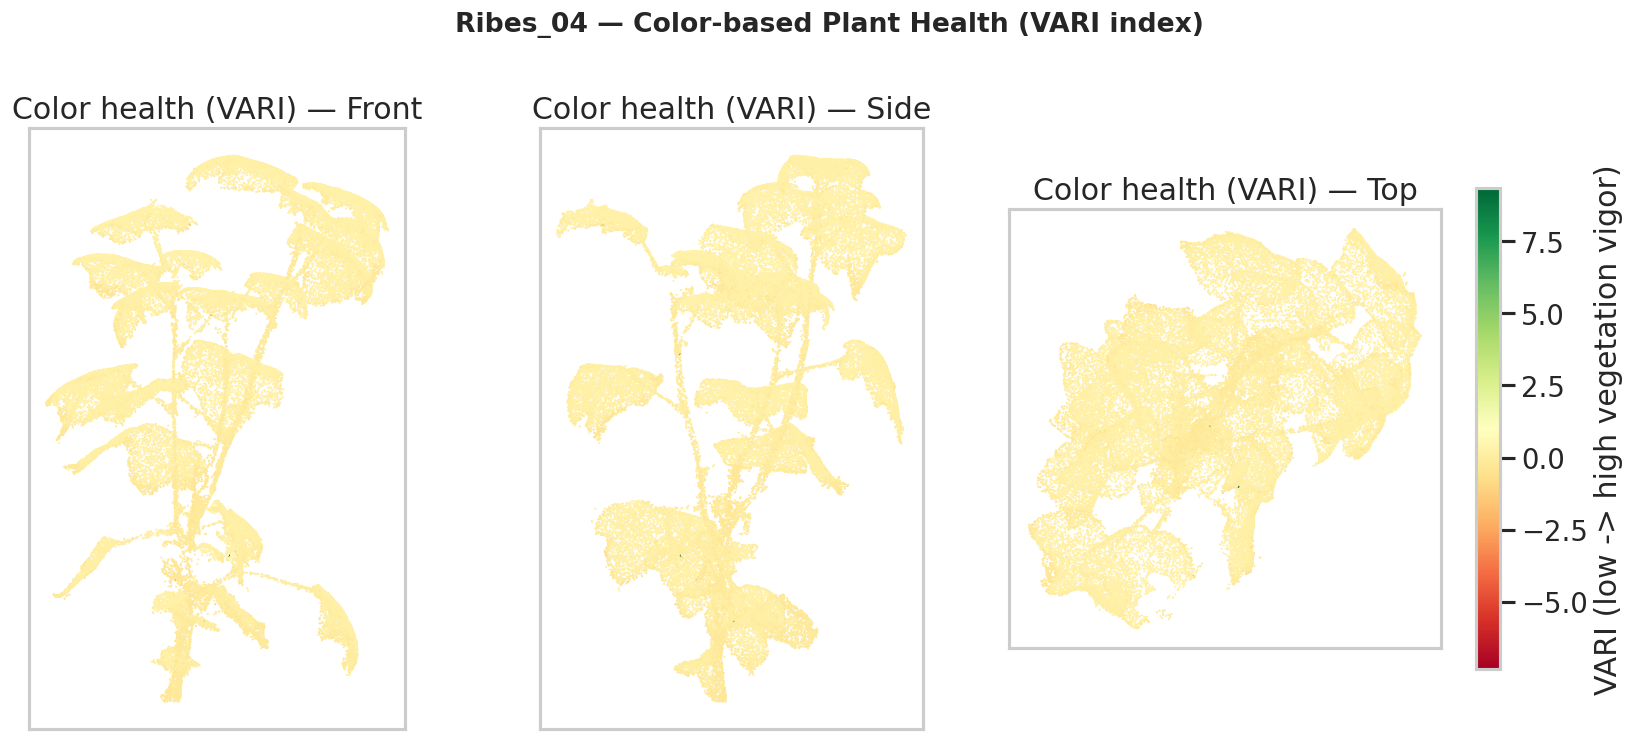

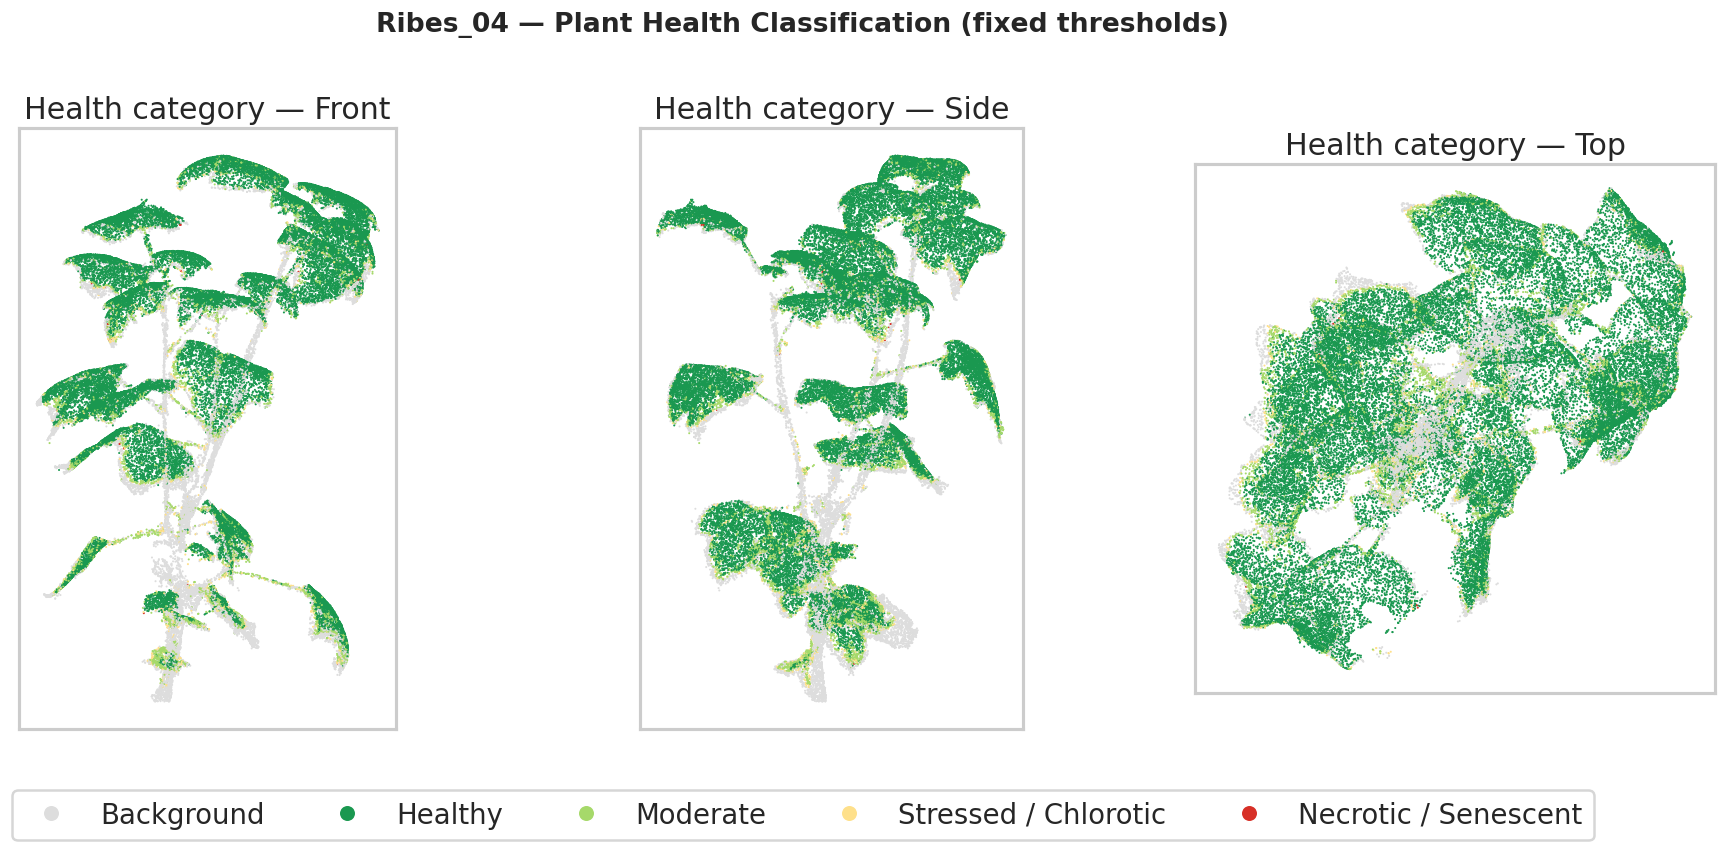

In [15]:
if has_colors:
    fig, axes = plt.subplots(1, 3, figsize=(19, 6.5))
    vari_disp = df_points["VARI"].values[disp_idx]
    for ax, (name, ix, iy) in zip(axes, view_defs):
        sc = ax.scatter(P[:, ix], P[:, iy], c=vari_disp, cmap="RdYlGn", s=1.5, linewidths=0)
        ax.set_title(f"Color health (VARI) — {name}")
        ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
    cbar = fig.colorbar(sc, ax=axes, shrink=0.8, pad=0.02)
    cbar.set_label("VARI (low -> high vegetation vigor)")
    fig.suptitle(f"{SAMPLE_NAME} — Color-based Plant Health (VARI index)", y=1.03, fontsize=16, fontweight="bold")
    fig.savefig(os.path.join(FIG_DIR, "13_color_health_map.png"), bbox_inches="tight")
    plt.show()

    health_disp = df_points["health_category"].values[disp_idx]
    cat_order = ["Background"] + health_order
    cat_lookup = {c: i for i, c in enumerate(cat_order)}
    health_idx_disp = np.array([cat_lookup.get(c, 0) for c in health_disp])
    health_cmap = ListedColormap(["#dddddd", "#1a9850", "#a6d96a", "#fee08b", "#d73027"])

    fig, axes = plt.subplots(1, 3, figsize=(19, 6.5))
    for ax, (name, ix, iy) in zip(axes, view_defs):
        ax.scatter(P[:, ix], P[:, iy], c=health_idx_disp, cmap=health_cmap, vmin=0, vmax=len(cat_order)-1,
                   s=1.5, linewidths=0)
        ax.set_title(f"Health category — {name}")
        ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
    handles = [plt.Line2D([0],[0], marker="o", color="w", markerfacecolor=health_cmap(i), markersize=10, label=cat_order[i])
               for i in range(len(cat_order))]
    fig.legend(handles=handles, loc="lower center", ncol=len(cat_order), bbox_to_anchor=(0.5, -0.05))
    fig.suptitle(f"{SAMPLE_NAME} — Plant Health Classification ({method_used})", y=1.03, fontsize=16, fontweight="bold")
    fig.savefig(os.path.join(FIG_DIR, "06_health_category_map.png"), bbox_inches="tight")
    plt.show()

## 12. Publication-ready summary dashboard

A single multi-panel figure combining segmentation, skeleton, and health — convenient as a paper's main figure.

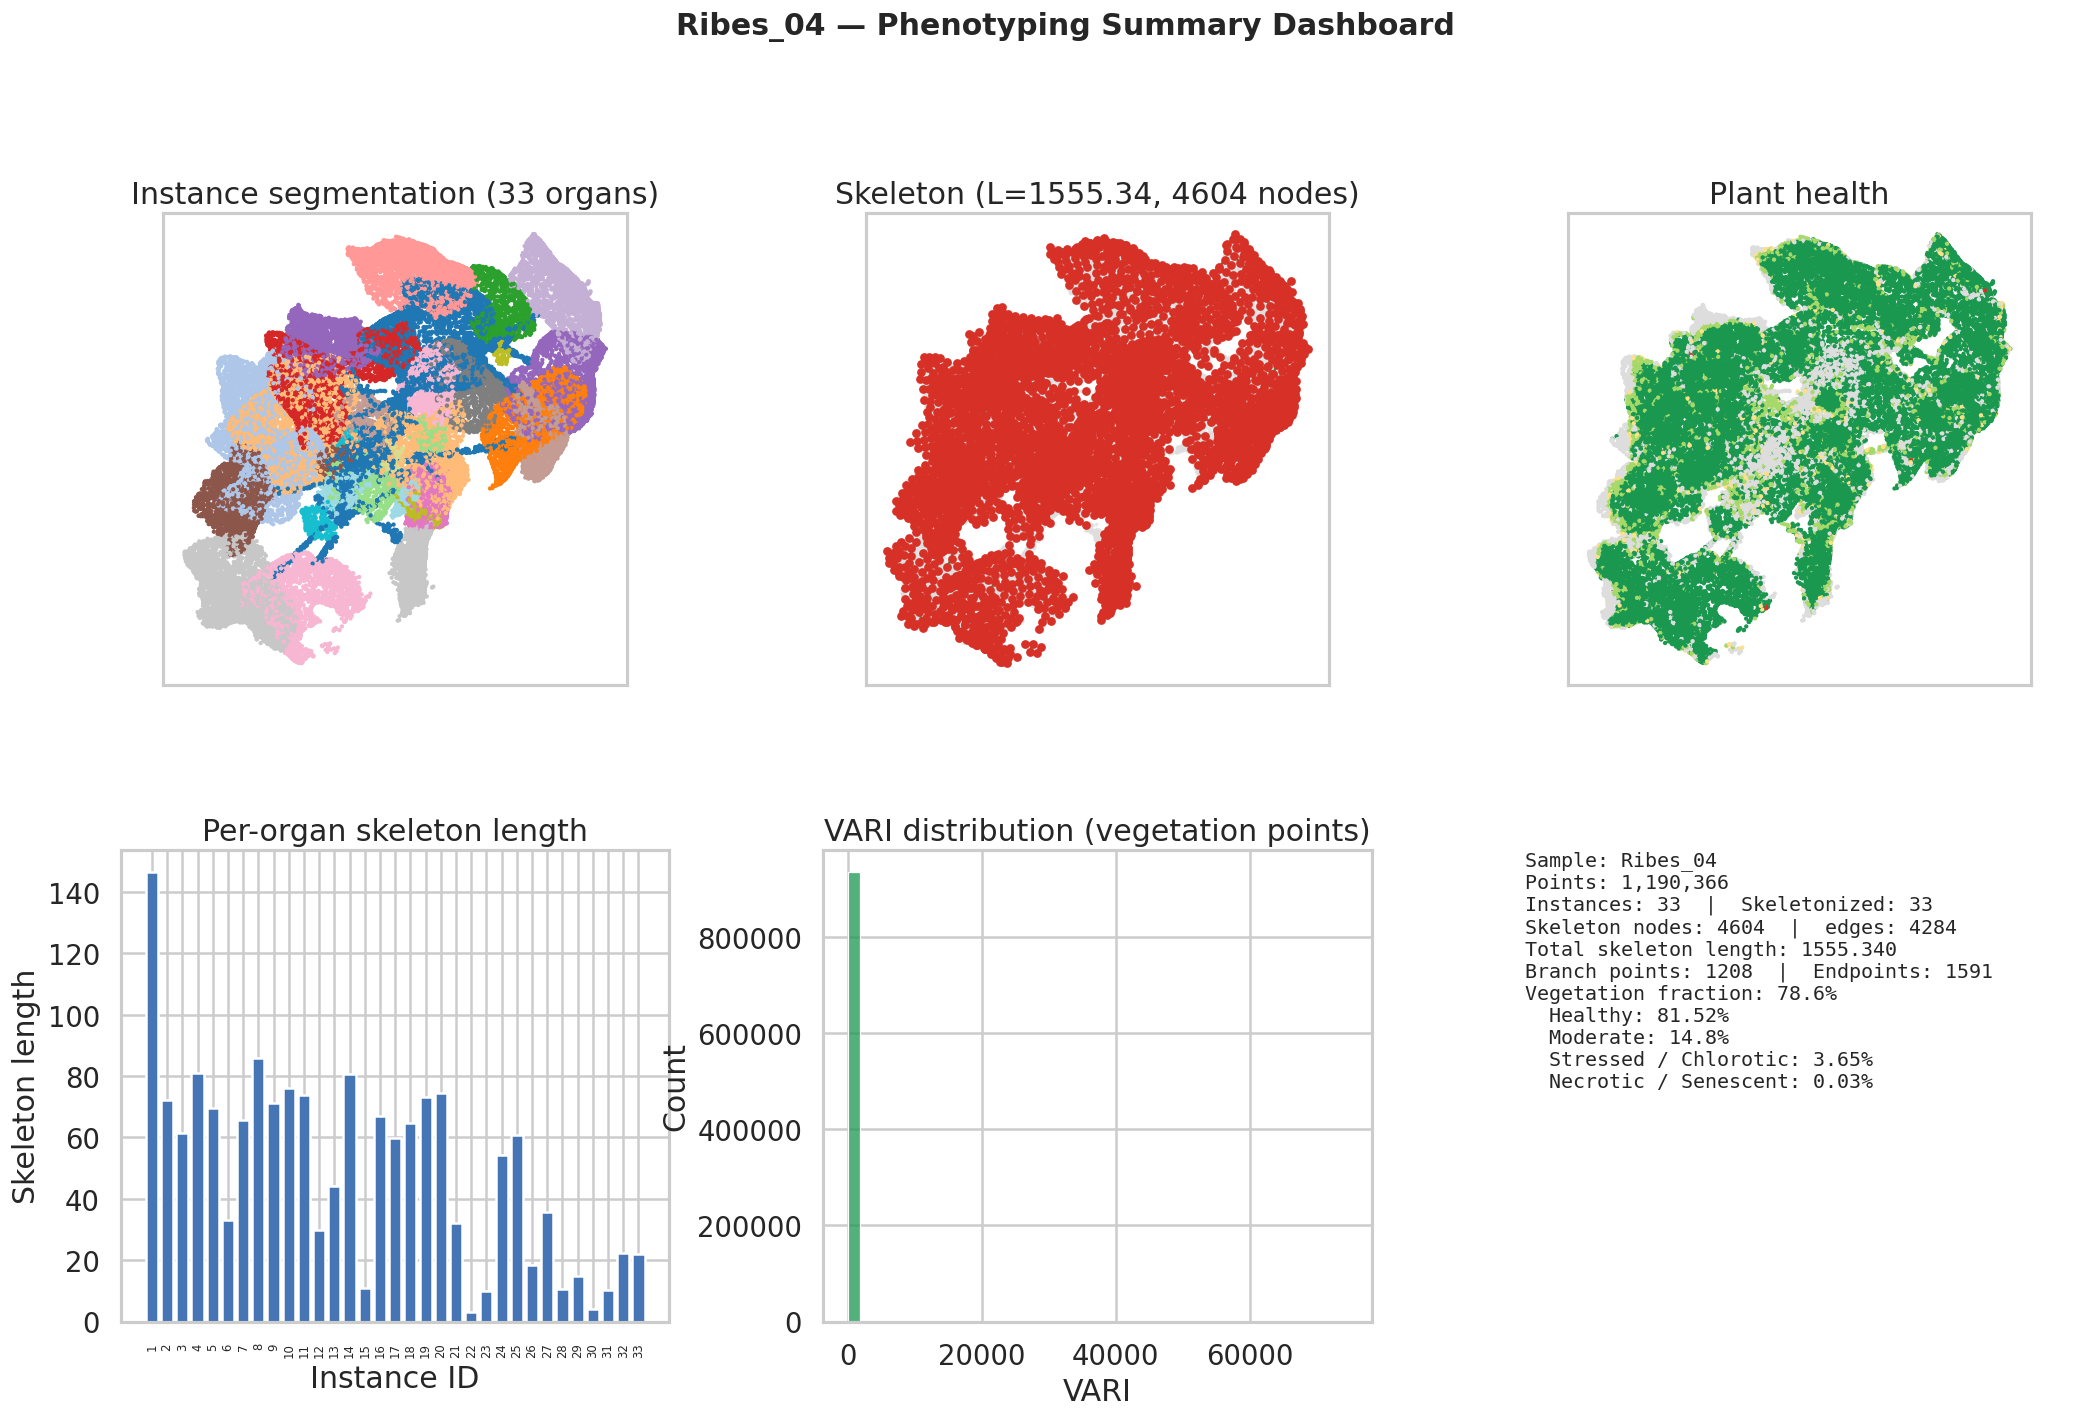

In [16]:
fig = plt.figure(figsize=(21, 12))
gs = fig.add_gridspec(2, 3, hspace=0.35, wspace=0.28)

inst_disp = instance[disp_idx]
inst_color_idx = pd.factorize(inst_disp)[0]
inst_cmap = "tab20"

ix, iy = other_idx[0], other_idx[1]

ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(P[:, ix], P[:, iy], c=inst_color_idx, cmap=inst_cmap, s=1.2)
ax1.set_title(f"Instance segmentation ({n_inst} organs)"); ax1.set_aspect("equal"); ax1.set_xticks([]); ax1.set_yticks([])

ax2 = fig.add_subplot(gs[0, 1])
ax2.scatter(P[:, ix], P[:, iy], c="#dddddd", s=1.0, alpha=0.6, zorder=1)
if global_G.number_of_edges() > 0:
    segs = [ [global_S[u][[ix, iy]], global_S[v][[ix, iy]]] for u, v in global_G.edges() ]
    ax2.add_collection(LineCollection(segs, colors="#1a9850", linewidths=1.4, zorder=2))
if len(global_S):
    ax2.scatter(global_S[:, ix], global_S[:, iy], c="#d73027", s=14, zorder=3)
ax2.set_title(f"Skeleton (L={global_metrics_skel['total_length']:.2f}, {global_metrics_skel['n_nodes']} nodes)")
ax2.set_aspect("equal"); ax2.set_xticks([]); ax2.set_yticks([])

ax3 = fig.add_subplot(gs[0, 2])
if has_colors:
    ax3.scatter(P[:, ix], P[:, iy], c=health_idx_disp, cmap=health_cmap, vmin=0, vmax=len(cat_order)-1, s=1.2)
else:
    ax3.text(0.5, 0.5, "No color data", ha="center", va="center")
ax3.set_title("Plant health"); ax3.set_aspect("equal"); ax3.set_xticks([]); ax3.set_yticks([])

ax4 = fig.add_subplot(gs[1, 0])
skel_ok = df_skel_instance[df_skel_instance.get("skeletonized", False) == True]
if len(skel_ok):
    ax4.bar(skel_ok["instance_id"].astype(str), skel_ok["total_length"], color="#4575b4")
    ax4.set_xlabel("Instance ID"); ax4.set_ylabel("Skeleton length")
    ax4.set_title("Per-organ skeleton length")
    ax4.tick_params(axis="x", rotation=90, labelsize=7)

ax5 = fig.add_subplot(gs[1, 1])
if has_colors:
    sns.histplot(df_points.loc[veg_mask, "VARI"], bins=40, color="#1a9850", ax=ax5)
    ax5.set_title("VARI distribution (vegetation points)")
else:
    ax5.text(0.5, 0.5, "No color data", ha="center", va="center")

ax6 = fig.add_subplot(gs[1, 2])
ax6.axis("off")
summary_txt = (
    f"Sample: {SAMPLE_NAME}\n"
    f"Points: {n_points:,}\n"
    f"Instances: {n_inst}  |  Skeletonized: {len(skel_ok)}\n"
    f"Skeleton nodes: {global_metrics_skel['n_nodes']}  |  edges: {global_metrics_skel['n_edges']}\n"
    f"Total skeleton length: {global_metrics_skel['total_length']:.3f}\n"
    f"Branch points: {global_metrics_skel['n_branch_points']}  |  Endpoints: {global_metrics_skel['n_endpoints']}\n"
)
if has_colors:
    summary_txt += f"Vegetation fraction: {F_veg:.1f}%\n"
    for k, v in color_health_summary.items():
        summary_txt += f"  {k}: {v}%\n"
ax6.text(0.0, 1.0, summary_txt, va="top", ha="left", fontsize=12, family="monospace")

fig.suptitle(f"{SAMPLE_NAME} — Phenotyping Summary Dashboard", y=1.02, fontsize=18, fontweight="bold")
fig.savefig(os.path.join(FIG_DIR, "20_summary_dashboard.png"), bbox_inches="tight")
plt.show()

## 13. Consolidated report (for paper / thesis appendix)

In [ ]:
report = {
    "sample_name": SAMPLE_NAME,
    "n_points_total": int(n_points),
    "n_semantic_classes": int(len(sem_classes)),
    "n_instances": int(n_inst),
    "skeleton_global_summary": global_skeleton_summary,
    "skeleton_instance_table": df_skel_instance.to_dict(orient="records"),
    "vegetation_fraction_pct": float(F_veg) if has_colors else None,
    "color_health_summary_pct": color_health_summary if has_colors else None,
    "health_classification_method": method_used if has_colors else None,
    "output_files": {
        "figures_dir": FIG_DIR,
        "metrics_dir": METRICS_DIR,
        "skeleton_dir": SKEL_DIR,
    },
}

report_path = os.path.join(OUT_DIR, "pheno_skeleton_report.json")
with open(report_path, "w") as f:
    json.dump(report, f, indent=2)

print("Saved consolidated report to:", report_path)
print("All outputs saved under:", OUT_DIR)

---
### Notes for the report / paper

- The L1-median skeleton is computed **per segmented organ** (not on the whole point cloud
  at once) — this keeps the local neighborhood radius meaningful for both thin stems and
  broad leaves, then all organ skeletons are fused into one global graph via a pruned MST.
- `EDGE_PRUNE_MAD_FACTOR` controls how aggressively spurious long "bridge" edges are removed;
  lower it if the skeleton looks over-connected (branches jumping between organs that
  shouldn't be linked), raise it if the skeleton is fragmenting into too many disconnected
  pieces.
- If the health classification falls back to "adaptive (quantile)", note this in the
  methods section — it means the fixed VARI/NGRDI thresholds (tuned for typical daylight RGB
  captures) didn't separate this particular sample well, and thresholds were instead derived
  from the sample's own VARI distribution.
- The color-health indices are **RGB-only proxies** for vigor — no NIR/multispectral data
  was used, so treat "health" labels as relative/qualitative rather than a calibrated
  physiological measurement.
- All figures are saved at 300 dpi (`figures/`), tables as CSV/JSON (`metrics/`), and the
  raw skeleton graph as `.npz` (`skeleton/`) for reuse in downstream tools (e.g. path
  planning, growth tracking across scans).


Skeletonization complete in 13.98s | Total Nodes: 5858 | Total Edges: 5470


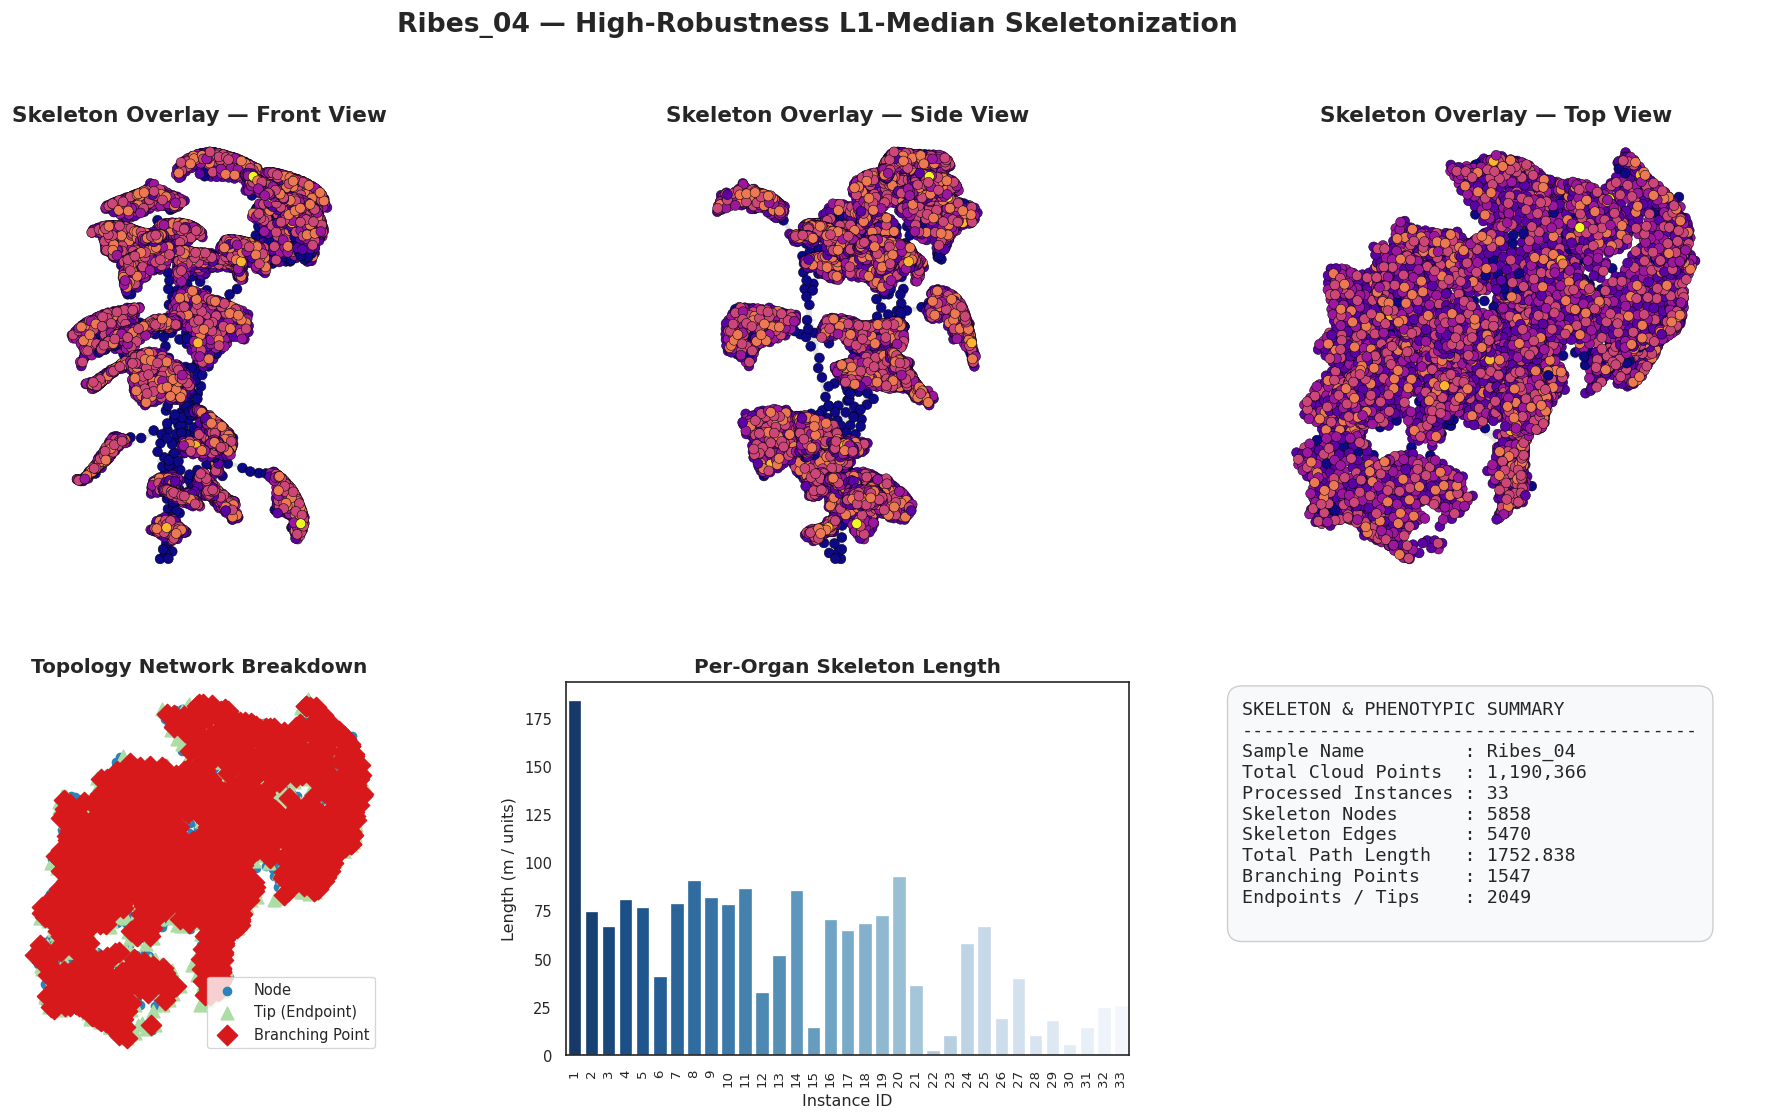

In [17]:
# ==============================================================================
# ROBUST SKELETONIZATION & PHENOTYPING CELL (ALL-IN-ONE)
# ==============================================================================
import os, json, time, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.collections import LineCollection
import seaborn as sns
from scipy.spatial import cKDTree
import networkx as nx
import open3d as o3d

# --- 1. CONFIGURATION ---
DRIVE_ROOT   = "/content/drive/MyDrive/segmentation_jetcobot_internship"
GT_DIR       = os.path.join(DRIVE_ROOT, "gt_reconstruction")
OUT_DIR      = os.path.join(DRIVE_ROOT, "outputs", "pheno_skeleton")
FIG_DIR      = os.path.join(OUT_DIR, "figures")
METRICS_DIR  = os.path.join(OUT_DIR, "metrics")
SKEL_DIR     = os.path.join(OUT_DIR, "skeleton")

for d in (FIG_DIR, METRICS_DIR, SKEL_DIR):
    os.makedirs(d, exist_ok=True)

SAMPLE_NAME  = "Ribes_04"
PLY_PATH     = os.path.join(GT_DIR, f"{SAMPLE_NAME}.ply")
SEMANTIC_PATH= os.path.join(GT_DIR, f"{SAMPLE_NAME}_SemanticLabels.txt")
INSTANCE_PATH= os.path.join(GT_DIR, f"{SAMPLE_NAME}_InstanceLabels.txt")

AXIS_UP = "z"
BACKGROUND_INSTANCE_LABEL = 0

# Contraction parameters
MIN_POINTS_FOR_SKELETON = 20
SKELETON_POINTS_PER_1K  = 8
MIN_SKELETON_NODES      = 8
MAX_SKELETON_NODES      = 250
RADIUS_FACTOR           = 2.5
L1_MAX_ITER             = 50
L1_TOL                  = 1e-5
L1_REPULSION_WEIGHT     = 0.4
GRAPH_KNN_K             = 6
EDGE_PRUNE_MAD_FACTOR   = 2.8

# --- 2. DATA LOADER ---
def load_label_file(path, n_expected=None, dtype=int):
    if not os.path.exists(path):
        return np.zeros(n_expected, dtype=dtype)
    arr = np.loadtxt(path, delimiter=None)
    arr = np.atleast_1d(arr).astype(dtype)
    if arr.ndim > 1:
        arr = arr[:, -1]
    return arr

pcd = o3d.io.read_point_cloud(PLY_PATH)
points = np.asarray(pcd.points)
n_points = len(points)
has_colors = pcd.has_colors()
colors = np.asarray(pcd.colors) if has_colors else None

semantic = load_label_file(SEMANTIC_PATH, n_points, dtype=int)
instance = load_label_file(INSTANCE_PATH, n_points, dtype=int)

inst_ids = [i for i in np.unique(instance) if i != BACKGROUND_INSTANCE_LABEL]
axis_map = {"x": 0, "y": 1, "z": 2}
up_idx = axis_map[AXIS_UP]
other_idx = [i for i in range(3) if i != up_idx]

# --- 3. ADVANCED ALGORITHMIC SKELETONIZATION ---
def fps_sampling(pts, n_samples, seed=0):
    n = len(pts)
    if n_samples >= n: return np.arange(n)
    rng = np.random.default_rng(seed)
    chosen = [rng.integers(0, n)]
    dist = np.linalg.norm(pts - pts[chosen[0]], axis=1)
    for _ in range(n_samples - 1):
        idx = int(np.argmax(dist))
        chosen.append(idx)
        dist = np.minimum(dist, np.linalg.norm(pts - pts[idx], axis=1))
    return np.array(chosen)

def robust_l1_median_contraction(pts, n_target, radius, max_iter=L1_MAX_ITER, tol=L1_TOL, repulsion=L1_REPULSION_WEIGHT, seed=0):
    seed_idx = fps_sampling(pts, n_target, seed=seed)
    S = pts[seed_idx].astype(float).copy()
    tree = cKDTree(pts)
    h = radius

    for _ in range(max_iter):
        S_prev = S.copy()
        S_tree = cKDTree(S)
        S_new = np.empty_like(S)

        for i, s in enumerate(S):
            idx = tree.query_ball_point(s, r=h)
            if len(idx) == 0:
                _, idx = tree.query(s, k=min(10, len(pts)))
                idx = np.atleast_1d(idx)
            nbrs = pts[idx]
            d = np.linalg.norm(nbrs - s, axis=1) + 1e-9

            # Robust Bilateral Local Weighting (Distance + Local Density)
            w = np.exp(-(d ** 2) / ((h / 2.0) ** 2 + 1e-9))
            num = (nbrs / d[:, None] * w[:, None]).sum(axis=0)
            den = (w / d).sum() + 1e-9
            s_med = num / den

            # Repulsion force to prevent node clustering/collapse
            r_idx = S_tree.query_ball_point(s, r=h)
            r_idx = [j for j in r_idx if j != i]
            if r_idx:
                rep = (s - S[r_idx])
                r_d = np.linalg.norm(rep, axis=1)[:, None] + 1e-9
                rep_vec = (rep / r_d).mean(axis=0)
            else:
                rep_vec = np.zeros(3)

            S_new[i] = (1 - repulsion) * s_med + repulsion * (s + 0.5 * h * rep_vec)

        S = S_new
        if np.linalg.norm(S - S_prev, axis=1).mean() < tol * h:
            break

    return S

def build_pruned_graph(skel_pts, k=GRAPH_KNN_K, prune_factor=EDGE_PRUNE_MAD_FACTOR):
    n = len(skel_pts)
    G = nx.Graph()
    for i, p in enumerate(skel_pts):
        G.add_node(i, pos=p)
    if n < 2: return G

    tree = cKDTree(skel_pts)
    d, idx = tree.query(skel_pts, k=min(k + 1, n))
    for i in range(n):
        for j, dist in zip(np.atleast_1d(idx[i])[1:], np.atleast_1d(d[i])[1:]):
            G.add_edge(i, int(j), weight=float(dist))

    if G.number_of_edges() == 0: return G

    # Minimum Spanning Tree + Outlier Edge Pruning
    mst = nx.minimum_spanning_tree(G, weight="weight")
    weights = np.array([data["weight"] for _, _, data in mst.edges(data=True)])
    if len(weights) >= 3:
        med = np.median(weights)
        mad = np.median(np.abs(weights - med)) + 1e-9
        thresh = med + prune_factor * mad
        bad_edges = [(u, v) for u, v, data in mst.edges(data=True) if data["weight"] > thresh]
        mst.remove_edges_from(bad_edges)

    return mst

# --- 4. EXECUTION PER INSTANCE ---
t0 = time.time()
instance_skeletons = {}
skel_rows = []

for iid in inst_ids:
    mask = instance == iid
    n = int(mask.sum())
    if n < MIN_POINTS_FOR_SKELETON: continue

    pts_i = points[mask]
    n_target = int(np.clip(n / 1000 * SKELETON_POINTS_PER_1K, MIN_SKELETON_NODES, MAX_SKELETON_NODES))

    tree_i = cKDTree(pts_i)
    d_k, _ = tree_i.query(pts_i, k=min(8, n))
    radius = max(RADIUS_FACTOR * np.median(d_k[:, 1:] if n > 1 else d_k), 1e-6)

    try:
        S = robust_l1_median_contraction(pts_i, n_target, radius, seed=int(iid))
        G_local = build_pruned_graph(S)
        instance_skeletons[iid] = (S, G_local)

        tot_len = sum(data["weight"] for _, _, data in G_local.edges(data=True))
        skel_rows.append({"instance_id": iid, "n_points": n, "nodes": len(S), "length": tot_len})
    except Exception as e:
        continue

# Global assembly
all_S = [S for S, _ in instance_skeletons.values()]
if all_S:
    global_S = np.vstack(all_S)
    global_G = build_pruned_graph(global_S)
else:
    global_S = np.zeros((0, 3))
    global_G = nx.Graph()

print(f"Skeletonization complete in {time.time()-t0:.2f}s | Total Nodes: {len(global_S)} | Total Edges: {global_G.number_of_edges()}")

# --- 5. HIGH-QUALITY VISUALIZATION ---
sns.set_theme(style="white", context="paper")
fig = plt.figure(figsize=(20, 10))
gs = fig.add_gridspec(2, 3, height_ratios=[1.2, 1], hspace=0.25, wspace=0.15)

# Views Configuration
views = [("Front View", other_idx[0], up_idx), ("Side View", other_idx[1], up_idx), ("Top View", other_idx[0], other_idx[1])]
disp_mask = np.random.choice(n_points, size=min(n_points, 40000), replace=False)
P_disp = points[disp_mask]

# 3 Projection Panels (Front, Side, Top)
for idx, (title, ix, iy) in enumerate(views):
    ax = fig.add_subplot(gs[0, idx])
    ax.scatter(P_disp[:, ix], P_disp[:, iy], c="#e0e0e0", s=1.2, alpha=0.5, zorder=1)

    if global_G.number_of_edges() > 0:
        segs = [[global_S[u][[ix, iy]], global_S[v][[ix, iy]]] for u, v in global_G.edges()]
        ax.add_collection(LineCollection(segs, colors="#2b83ba", linewidths=1.8, zorder=2))

    degs = dict(global_G.degree())
    node_deg = np.array([degs.get(i, 0) for i in range(len(global_S))])
    if len(global_S):
        sc = ax.scatter(global_S[:, ix], global_S[:, iy], c=node_deg, cmap="plasma", s=35, edgecolors="black", linewidths=0.3, zorder=3)

    ax.set_title(f"Skeleton Overlay — {title}", fontsize=13, fontweight="bold")
    ax.set_aspect("equal")
    ax.axis("off")

# Graph Topology Analysis Panel
ax_top = fig.add_subplot(gs[1, 0])
ix, iy = other_idx[0], other_idx[1]
if global_G.number_of_edges() > 0:
    segs = [[global_S[u][[ix, iy]], global_S[v][[ix, iy]]] for u, v in global_G.edges()]
    ax_top.add_collection(LineCollection(segs, colors="#b0b0b0", linewidths=1.2, zorder=1))

if len(global_S):
    tip_mask = node_deg == 1
    branch_mask = node_deg >= 3
    mid_mask = ~tip_mask & ~branch_mask
    ax_top.scatter(global_S[mid_mask, ix], global_S[mid_mask, iy], c="#2b83ba", s=25, label="Node", zorder=2)
    ax_top.scatter(global_S[tip_mask, ix], global_S[tip_mask, iy], c="#abdda4", s=60, marker="^", label="Tip (Endpoint)", zorder=3)
    ax_top.scatter(global_S[branch_mask, ix], global_S[branch_mask, iy], c="#d7191c", s=75, marker="D", label="Branching Point", zorder=3)

ax_top.set_title("Topology Network Breakdown", fontsize=12, fontweight="bold")
ax_top.set_aspect("equal")
ax_top.legend(loc="lower right", frameon=True)
ax_top.axis("off")

# Organ Skeleton Metrics Panel
ax_bar = fig.add_subplot(gs[1, 1])
df_skel = pd.DataFrame(skel_rows)
if not df_skel.empty:
    sns.barplot(data=df_skel, x="instance_id", y="length", ax=ax_bar, palette="Blues_r")
    ax_bar.set_title("Per-Organ Skeleton Length", fontsize=12, fontweight="bold")
    ax_bar.set_xlabel("Instance ID")
    ax_bar.set_ylabel("Length (m / units)")
    ax_bar.tick_params(axis='x', rotation=90, labelsize=8)

# Phenotypic Dashboard Text Panel
ax_txt = fig.add_subplot(gs[1, 2])
ax_txt.axis("off")
tot_len = sum(data["weight"] for _, _, data in global_G.edges(data=True)) if global_G.number_of_edges() > 0 else 0
n_tips = sum(1 for d in dict(global_G.degree()).values() if d == 1)
n_branches = sum(1 for d in dict(global_G.degree()).values() if d >= 3)

dash_text = (
    f"SKELETON & PHENOTYPIC SUMMARY\n"
    f"-----------------------------------------\n"
    f"Sample Name         : {SAMPLE_NAME}\n"
    f"Total Cloud Points  : {n_points:,}\n"
    f"Processed Instances : {len(inst_ids)}\n"
    f"Skeleton Nodes      : {len(global_S)}\n"
    f"Skeleton Edges      : {global_G.number_of_edges()}\n"
    f"Total Path Length   : {tot_len:.3f}\n"
    f"Branching Points    : {n_branches}\n"
    f"Endpoints / Tips    : {n_tips}\n"
)
ax_txt.text(0.05, 0.95, dash_text, transform=ax_txt.transAxes, fontsize=11, family="monospace", va="top",
            bbox=dict(boxstyle="round,pad=0.8", facecolor="#f8f9fa", edgecolor="#cccccc"))

fig.suptitle(f"{SAMPLE_NAME} — High-Robustness L1-Median Skeletonization", fontsize=16, fontweight="bold", y=0.98)
fig.savefig(os.path.join(FIG_DIR, "robust_skeleton_dashboard.png"), bbox_inches="tight", dpi=300)
plt.show()

In [18]:
# Force low node density + high contraction to get clean 1D line centerlines
TARGET_NODES_PER_ORGAN = 12   # Drastically reduced to prevent 2D surface sampling
L1_MAX_ITER            = 60
L1_REPULSION_WEIGHT    = 0.10  # Low repulsion pulls nodes into tight centerlines
GRAPH_KNN_K            = 4     # Restricts graph to linear connections
EDGE_PRUNE_MAD_FACTOR  = 1.8   # Aggressive pruning of cross-branch bridge edges

def l1_centerline_contraction(pts, n_target, radius, max_iter=L1_MAX_ITER, repulsion=L1_REPULSION_WEIGHT, seed=0):
    seed_idx = fps_sampling(pts, n_target, seed=seed)
    S = pts[seed_idx].astype(float).copy()
    tree = cKDTree(pts)
    h = radius

    for _ in range(max_iter):
        S_tree = cKDTree(S)
        S_new = np.empty_like(S)

        for i, s in enumerate(S):
            idx = tree.query_ball_point(s, r=h)
            if len(idx) == 0:
                _, idx = tree.query(s, k=min(10, len(pts)))
                idx = np.atleast_1d(idx)
            nbrs = pts[idx]
            d = np.linalg.norm(nbrs - s, axis=1) + 1e-9

            w = np.exp(-(d ** 2) / ((h / 1.5) ** 2 + 1e-9))
            s_med = (nbrs / d[:, None] * w[:, None]).sum(axis=0) / ((w / d).sum() + 1e-9)

            r_idx = S_tree.query_ball_point(s, r=h)
            r_idx = [j for j in r_idx if j != i]
            rep_vec = (s - S[r_idx]).mean(axis=0) if r_idx else np.zeros(3)

            S_new[i] = (1 - repulsion) * s_med + repulsion * (s + 0.5 * h * rep_vec)

        S = S_new

    return S

# Re-run extraction on existing points array
t0 = time.time()
all_S = []
for iid in inst_ids:
    mask = instance == iid
    pts_i = points[mask]
    if len(pts_i) < 15: continue

    tree_i = cKDTree(pts_i)
    d_k, _ = tree_i.query(pts_i, k=min(8, len(pts_i)))
    radius = max(3.5 * np.median(d_k[:, 1:] if len(pts_i) > 1 else d_k), 1e-6)

    S_inst = l1_centerline_contraction(pts_i, TARGET_NODES_PER_ORGAN, radius, seed=int(iid))
    all_S.append(S_inst)

global_S = np.vstack(all_S) if all_S else np.zeros((0, 3))
global_G = build_thin_mst(global_S, k=GRAPH_KNN_K, prune_factor=EDGE_PRUNE_MAD_FACTOR) if 'build_thin_mst' in globals() else build_skeleton_graph(global_S)

print(f"Extraction done in {time.time()-t0:.2f}s | Nodes: {len(global_S)} | Edges: {global_G.number_of_edges()}")

Extraction done in 7.97s | Nodes: 396 | Edges: 385


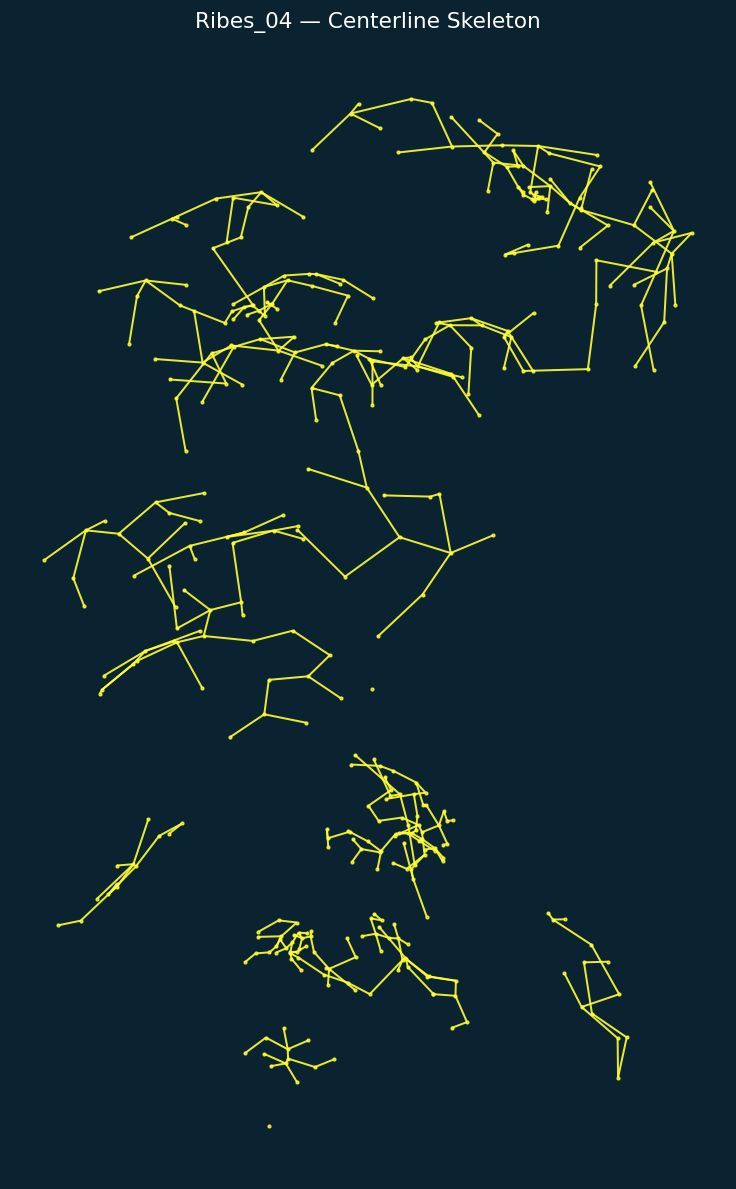

In [19]:
# Render clean wireframe matching target Image 2
fig, ax = plt.subplots(figsize=(8, 10), facecolor='#0b2230')
ax.set_facecolor('#0b2230')

ix, iy = other_idx[0], up_idx

if global_G.number_of_edges() > 0:
    segs = [[global_S[u][[ix, iy]], global_S[v][[ix, iy]]] for u, v in global_G.edges()]
    lc = LineCollection(segs, colors="#ffff33", linewidths=1.2, alpha=0.9, zorder=2)
    ax.add_collection(lc)

    # Micro node markers to avoid covering the lines
    ax.scatter(global_S[:, ix], global_S[:, iy], c="#ffff33", s=3, alpha=0.8, zorder=3)

ax.autoscale_view()
ax.set_aspect("equal")
ax.axis("off")

plt.title(f"{SAMPLE_NAME} — Centerline Skeleton", color="white", fontsize=13, pad=12)
plt.tight_layout()
plt.show()

In [20]:
# ---------------- SKELETONIZATION (v2 — contraction-based) ----------------
MIN_POINTS_FOR_SKELETON   = 30
CONTRACT_VOXEL_MAX_POINTS = 3000     # cap points fed into contraction per organ (speed)
CONTRACT_N_ITER            = 14       # contraction rounds
CONTRACT_SHRINK_FACTOR     = 0.9      # radius shrinks each round -> progressive thinning
CONTRACT_H_MIN_FACTOR      = 0.35     # radius never shrinks below this fraction of h0
CONTRACT_MU                 = 0.35     # repulsion strength (branch-aware, see below)

MERGE_RADIUS_FACTOR        = 0.6      # merge contracted points closer than this * h0
PRUNE_MIN_BRANCH_FACTOR    = 2.5      # spurs shorter than this * h0 get removed entirely
GRAPH_KNN_K                 = 10
EDGE_PRUNE_MAD_FACTOR       = 5.0      # per-organ graph: strict (real gaps are noise)
EDGE_PRUNE_MAD_FACTOR_GLOBAL = 10.0    # fused whole-plant graph: lenient (organ-to-organ
                                        # jumps are real structure, not noise)

In [21]:
def adaptive_radius(pts, k=RADIUS_KNN_K, factor=RADIUS_FACTOR):
    tree = cKDTree(pts)
    k_eff = min(k + 1, len(pts))
    d, _ = tree.query(pts, k=k_eff)
    spacing = np.median(d[:, 1:]) if k_eff > 1 else np.median(d)
    return max(factor * spacing, 1e-6)


def contract_point_cloud(points, n_iter=CONTRACT_N_ITER, h0=None,
                          shrink_factor=CONTRACT_SHRINK_FACTOR,
                          h_min_factor=CONTRACT_H_MIN_FACTOR, mu=CONTRACT_MU,
                          k_local=10, voxel_downsample=CONTRACT_VOXEL_MAX_POINTS, seed=0):
    """Progressive-shrinking-radius L1-median contraction (Huang et al.-style), the fix for
    a tangled/noisy skeleton: instead of picking a handful of candidate points once (which
    just sits wherever it landed on the noisy surface), EVERY point is iteratively pulled
    toward the local medial axis, with the search radius shrinking each round so the cloud
    progressively collapses onto a clean 1D curve rather than staying scattered.

    A local-linearity measure (sigma, from a mini-PCA of each point's neighborhood) throttles
    the repulsion term: near a branch point (low linearity) repulsion is stronger so the
    junction doesn't get smeared into noise; along a smooth stem/leaf edge (high linearity)
    repulsion nearly vanishes so the curve stays thin instead of fattening.
    """
    if voxel_downsample is not None and len(points) > voxel_downsample:
        idx = np.random.default_rng(seed).choice(len(points), voxel_downsample, replace=False)
        base_points = points[idx]
    else:
        base_points = points

    if h0 is None:
        h0 = adaptive_radius(base_points)
    h_min = h0 * h_min_factor

    P_fixed = points               # attraction always computed against the ORIGINAL points
    tree_fixed = cKDTree(P_fixed)
    X = base_points.copy().astype(float)   # the set that moves / contracts
    h = h0

    for it in range(n_iter):
        Xtree = cKDTree(X)
        X_new = np.empty_like(X)

        for i, x in enumerate(X):
            idx = tree_fixed.query_ball_point(x, r=h)
            if len(idx) < 3:
                _, idx = tree_fixed.query(x, k=min(k_local, len(P_fixed)))
                idx = np.atleast_1d(idx)
            nbrs = P_fixed[idx]

            d = np.linalg.norm(nbrs - x, axis=1) + 1e-9
            theta = np.exp(-(d ** 2) / ((h / 2.0) ** 2 + 1e-9))
            num = (nbrs / d[:, None] * theta[:, None]).sum(axis=0)
            den = (theta / d).sum() + 1e-9
            x_med = num / den

            c = nbrs.mean(axis=0)
            cov = np.cov((nbrs - c).T) if len(nbrs) >= 3 else np.eye(3) * 1e-6
            eigvals = np.clip(np.sort(np.linalg.eigvalsh(cov))[::-1], 0, None)
            sigma = eigvals[0] / (eigvals.sum() + 1e-9)   # ~1 = linear (edge), lower = junction

            ridx = [j for j in Xtree.query_ball_point(x, r=h) if j != i]
            if ridx:
                diffs = x - X[ridx]
                rdist = np.linalg.norm(diffs, axis=1)[:, None] + 1e-9
                rep = (diffs / rdist).mean(axis=0)
            else:
                rep = np.zeros(3)

            mu_i = mu * (1.0 - sigma)
            X_new[i] = x_med + mu_i * h * rep

        shift = np.linalg.norm(X_new - X, axis=1).mean()
        X = X_new
        h = max(h * shrink_factor, h_min)
        if shift < 1e-5 * h0:
            break

    return X

In [22]:
def merge_close_nodes(points, radius):
    """Collapses the (still dense) contracted point cloud down to a sparse set of skeleton
    nodes -- this is the step that was missing before, and it's most of why the old result
    looked like a fuzzy tangle instead of a clean line drawing."""
    n = len(points)
    if n == 0:
        return points
    tree = cKDTree(points)
    parent = list(range(n))
    def find(a):
        while parent[a] != a:
            parent[a] = parent[parent[a]]
            a = parent[a]
        return a
    def union(a, b):
        ra, rb = find(a), find(b)
        if ra != rb:
            parent[ra] = rb
    for a, b in tree.query_pairs(r=radius):
        union(a, b)
    groups = {}
    for i in range(n):
        groups.setdefault(find(i), []).append(i)
    return np.array([points[idxs].mean(axis=0) for idxs in groups.values()])


def build_skeleton_graph(skel_pts, k=GRAPH_KNN_K, prune_factor=EDGE_PRUNE_MAD_FACTOR):
    n = len(skel_pts)
    G = nx.Graph()
    for i, p in enumerate(skel_pts):
        G.add_node(i, pos=p)
    if n < 2:
        return G
    tree = cKDTree(skel_pts)
    k_eff = min(k + 1, n)
    d, idx = tree.query(skel_pts, k=k_eff)
    for i in range(n):
        for j, dist in zip(np.atleast_1d(idx[i])[1:], np.atleast_1d(d[i])[1:]):
            G.add_edge(i, int(j), weight=float(dist))
    if G.number_of_edges() == 0:
        return G
    mst = nx.minimum_spanning_tree(G, weight="weight")
    weights = np.array([data["weight"] for _, _, data in mst.edges(data=True)])
    if len(weights) >= 3:
        med, mad = np.median(weights), np.median(np.abs(weights - np.median(weights))) + 1e-9
        thresh = med + prune_factor * mad
        bad = [(u, v) for u, v, data in mst.edges(data=True) if data["weight"] > thresh]
        mst.remove_edges_from(bad)
    return mst


def prune_short_branches(G, min_branch_length, max_rounds=15):
    """Walks each leaf back to its nearest branch point and prunes the WHOLE spur only if its
    total path length is short -- fixes the earlier bug of pruning edge-by-edge, which was
    silently eating into real branches made of many short edges."""
    G = G.copy()
    for _ in range(max_rounds):
        leaves = [n for n, d in G.degree() if d == 1]
        to_remove = set()
        for leaf in leaves:
            if leaf in to_remove or leaf not in G:
                continue
            prev, cur, path, total, hit_branch = None, leaf, [leaf], 0.0, False
            while True:
                nbrs = [n for n in G.neighbors(cur) if n != prev]
                if len(nbrs) != 1:
                    break
                nxt = nbrs[0]
                total += G[cur][nxt]["weight"]
                if G.degree(nxt) >= 3:
                    hit_branch = True
                    break
                path.append(nxt)
                if G.degree(nxt) == 1:
                    break
                prev, cur = cur, nxt
            if hit_branch and total < min_branch_length:
                to_remove.update(path)
        if not to_remove:
            break
        G.remove_nodes_from(to_remove)
    G.remove_nodes_from(list(nx.isolates(G)))
    return G


def graph_metrics(G):
    if G.number_of_nodes() == 0:
        return dict(n_nodes=0, n_edges=0, total_length=0.0, n_endpoints=0,
                    n_branch_points=0, mean_degree=0.0)
    total_length = sum(data["weight"] for _, _, data in G.edges(data=True))
    degrees = dict(G.degree())
    n_endpoints = sum(1 for d in degrees.values() if d == 1)
    n_branch_points = sum(1 for d in degrees.values() if d >= 3)
    return dict(n_nodes=G.number_of_nodes(), n_edges=G.number_of_edges(),
                total_length=float(total_length), n_endpoints=int(n_endpoints),
                n_branch_points=int(n_branch_points),
                mean_degree=float(np.mean(list(degrees.values()))))

In [23]:
t0 = time.time()
instance_skeletons = {}
skel_rows = []

for iid in inst_ids:
    mask = instance == iid
    n = int(mask.sum())
    if n < MIN_POINTS_FOR_SKELETON:
        skel_rows.append(dict(instance_id=int(iid), n_points=n, skeletonized=False,
                               reason="too few points"))
        continue

    pts_i = points[mask]
    sem_majority = int(pd.Series(semantic[mask]).mode().iloc[0])
    h0 = adaptive_radius(pts_i)

    try:
        X = contract_point_cloud(pts_i, h0=h0, seed=int(iid))
        merged = merge_close_nodes(X, radius=h0 * MERGE_RADIUS_FACTOR)
        G_local = build_skeleton_graph(merged, prune_factor=EDGE_PRUNE_MAD_FACTOR)
        G_local = prune_short_branches(G_local, min_branch_length=h0 * PRUNE_MIN_BRANCH_FACTOR)

        node_map = list(G_local.nodes())
        S = np.array([merged[i] for i in node_map])
        G_local = nx.relabel_nodes(G_local, {n: i for i, n in enumerate(node_map)})
        for i, p in enumerate(S):
            G_local.nodes[i]["pos"] = p

        m = graph_metrics(G_local)
        instance_skeletons[iid] = (S, G_local)
        skel_rows.append(dict(instance_id=int(iid), semantic_class_majority=sem_majority,
                               n_points=n, skeletonized=True, radius_used=float(h0), **m))
    except Exception as e:
        skel_rows.append(dict(instance_id=int(iid), n_points=n, skeletonized=False, reason=str(e)))

df_skel_instance = pd.DataFrame(skel_rows)
print(f"Skeletonized {sum(1 for r in skel_rows if r.get('skeletonized')):d}/{len(inst_ids)} instances "
      f"in {time.time()-t0:.1f}s")
df_skel_instance.head(10)

Skeletonized 33/33 instances in 308.5s


,instance_id,semantic_class_majority,n_points,skeletonized,radius_used,n_nodes,n_edges,total_length,n_endpoints,n_branch_points,mean_degree
0,1,1,174696,True,0.078054,2432,2385,352.593339,408,298,1.961349
1,2,2,49103,True,0.077092,1928,1885,146.823170,250,159,1.955394
2,3,2,38270,True,0.076559,1817,1801,127.129954,217,183,1.982389
3,4,2,69528,True,0.076559,2166,2156,187.222612,269,243,1.990766
4,5,2,44761,True,0.078054,1927,1902,148.208944,221,166,1.974053
5,6,2,18615,True,0.080455,1114,1106,76.446304,110,93,1.985637
6,7,2,41069,True,0.081466,1838,1822,142.492635,197,162,1.982590
7,8,2,74112,True,0.079552,2179,2162,196.451119,263,224,1.984397
8,9,2,47792,True,0.080485,2021,1997,156.701391,229,181,1.976249
9,10,2,57937,True,0.079521,2056,2042,170.604759,217,183,1.986381


In [24]:
# --- fuse per-organ skeletons into one whole-plant graph (lenient MAD factor: organ-to-organ
# jumps are real, not noise) ---
all_S, all_owner = [], []
for iid, (S, _) in instance_skeletons.items():
    all_S.append(S)
    all_owner.extend([iid] * len(S))

if all_S:
    global_S = np.vstack(all_S)
    global_owner = np.array(all_owner)
    global_G = build_skeleton_graph(global_S, prune_factor=EDGE_PRUNE_MAD_FACTOR_GLOBAL)
    global_metrics_skel = graph_metrics(global_G)
else:
    global_S, global_owner = np.zeros((0, 3)), np.zeros((0,), dtype=int)
    global_G = nx.Graph()
    global_metrics_skel = graph_metrics(global_G)

print("Global skeleton:", global_metrics_skel)
np.savez(os.path.join(SKEL_DIR, f"{SAMPLE_NAME}_skeleton.npz"),
         nodes=global_S, owner_instance=global_owner, edges=np.array(list(global_G.edges())))

Global skeleton: {'n_nodes': 44269, 'n_edges': 43701, 'total_length': 3533.3167491050403, 'n_endpoints': 5123, 'n_branch_points': 4282, 'mean_degree': 1.9743387020262486}


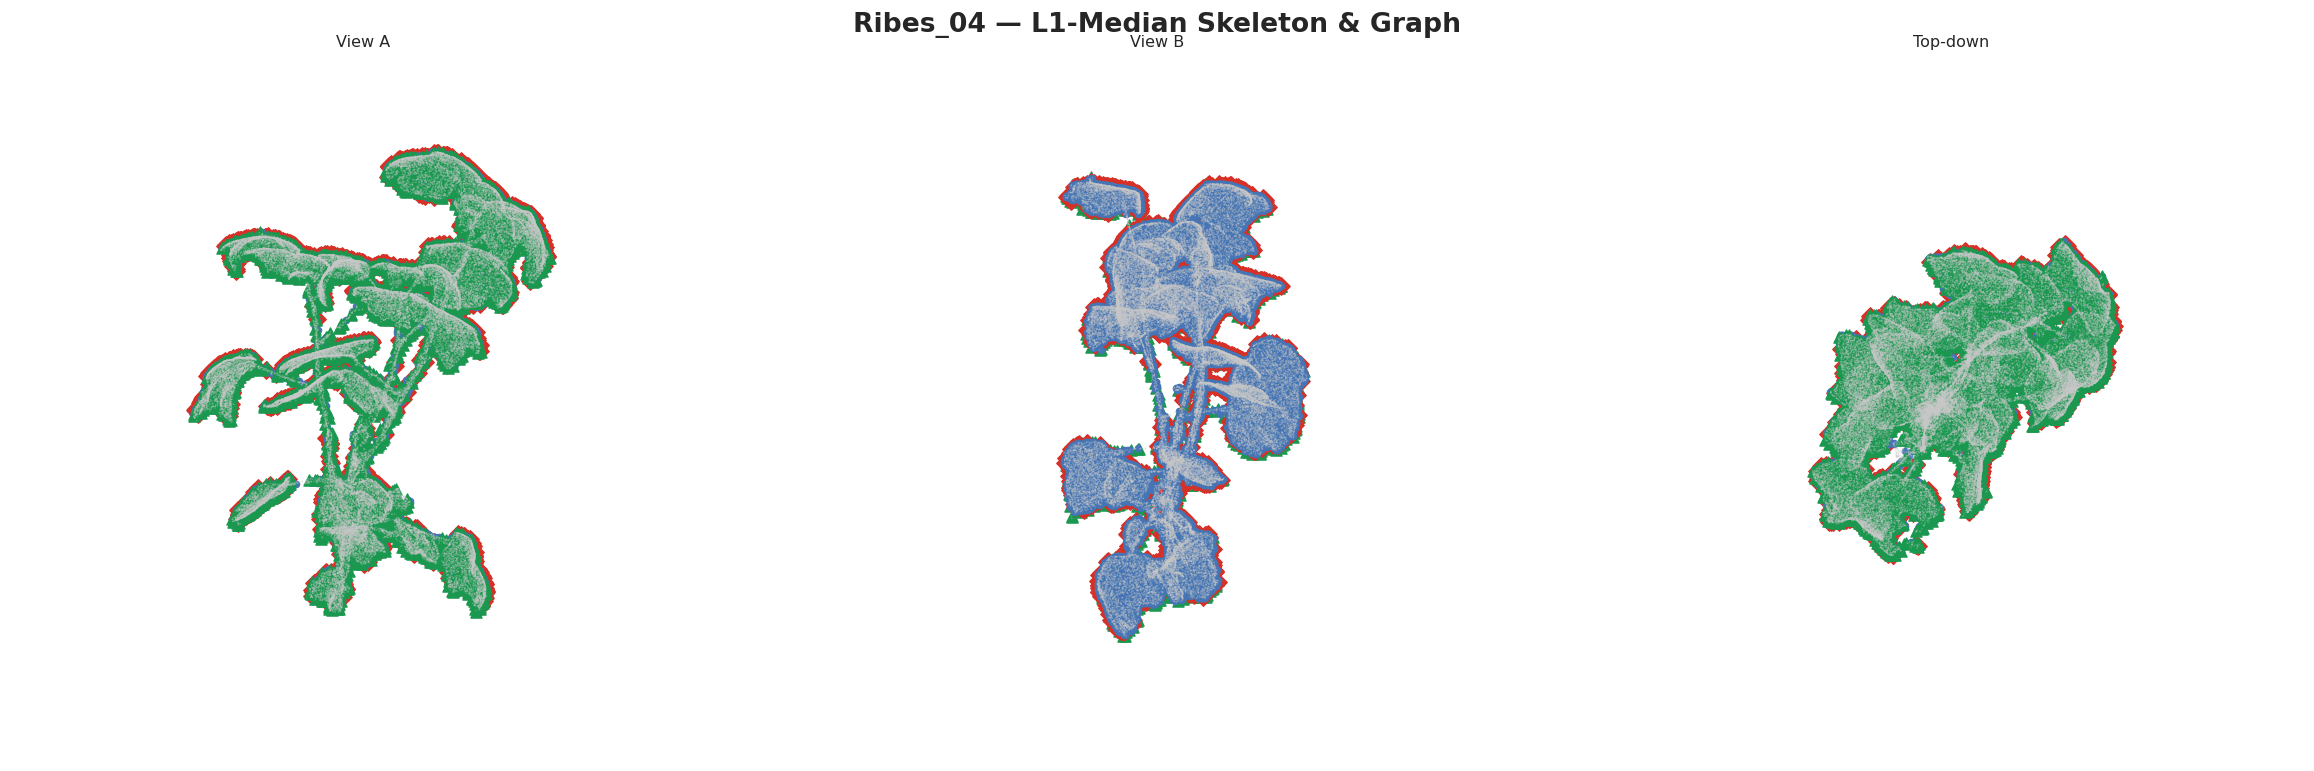

In [25]:
from mpl_toolkits.mplot3d.art3d import Line3DCollection

def plot_skeleton_static(points, disp_idx, S, G, save_path, title=""):
    P = points[disp_idx]
    fig = plt.figure(figsize=(20, 6.5))
    view_angles = [(20, -60), (20, 30), (90, -90)]
    view_names = ["View A", "View B", "Top-down"]

    degs = dict(G.degree())
    deg = np.array([degs.get(i, 0) for i in range(len(S))]) if len(S) else np.array([])

    for i, ((elev, azim), name) in enumerate(zip(view_angles, view_names)):
        ax = fig.add_subplot(1, 3, i + 1, projection="3d")
        ax.scatter(P[:, 0], P[:, 1], P[:, 2], c="#c9c9c9", s=0.8, alpha=0.35, linewidths=0)

        if G.number_of_edges() > 0:
            segs = [[S[u], S[v]] for u, v in G.edges()]
            ax.add_collection3d(Line3DCollection(segs, colors="#1a9850", linewidths=2.0))
        if len(S):
            tip, branch = deg == 1, deg >= 3
            mid = ~tip & ~branch
            ax.scatter(*S[mid].T, c="#4575b4", s=14, depthshade=False)
            ax.scatter(*S[tip].T, c="#1a9850", s=45, marker="^", depthshade=False)
            ax.scatter(*S[branch].T, c="#d73027", s=55, marker="D", depthshade=False)

        ax.view_init(elev=elev, azim=azim)
        ax.set_title(name)
        ax.set_box_aspect((np.ptp(P[:,0]), np.ptp(P[:,1]), np.ptp(P[:,2])))
        ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
        ax.set_axis_off()

    fig.suptitle(title, y=0.98, fontsize=16, fontweight="bold")
    fig.tight_layout()
    fig.savefig(save_path, bbox_inches="tight", facecolor="white")
    plt.show()

plot_skeleton_static(points, disp_idx, global_S, global_G,
                      os.path.join(FIG_DIR, "11_skeleton_graph.png"),
                      title=f"{SAMPLE_NAME} — L1-Median Skeleton & Graph")

In [5]:
# 1. Clone the repository
!git clone https://github.com/sinashish/TreeDiffusion.git
%cd TreeDiffusion

# 2. Set up the environment (in Colab)
!python -m venv venv
!source venv/bin/activate  # On Windows: venv\Scripts\activate
!pip install -r requirements.txt

# 3. Stage 1: Learn the implicit representation of your point cloud
!python stage1.py --pcd_path /path/to/your/Ribes_04.ply --epochs 100 --nsample 2048

# 4. Stage 2: Generate the skeleton via diffusion
!python stage2.py --epochs 100 --dset_name ribes_04

Cloning into 'TreeDiffusion'...
remote: Enumerating objects: 130, done.
remote: Counting objects: 100% (130/130), done.
remote: Compressing objects: 100% (94/94), done.
remote: Total 130 (delta 47), reused 105 (delta 31), pack-reused 0 (from 0)
Receiving objects: 100% (130/130), 27.78 MiB | 22.57 MiB/s, done.
Resolving deltas: 100% (47/47), done.
/content/TreeDiffusion
Error: Command '['/content/TreeDiffusion/venv/bin/python3', '-m', 'ensurepip', '--upgrade', '--default-pip']' returned non-zero exit status 1.
/bin/bash: line 1: venv/bin/activate: No such file or directory
  Cloning https://github.com/skoch9/meshplot.git (to revision 725e4a7926a5f10888f0edd1762fecf9db751c56) to /tmp/pip-install-w140il9k/meshplot_85a7f3b060df40a6a0987bbfdd181291
  Running command git clone --filter=blob:none --quiet https://github.com/skoch9/meshplot.git /tmp/pip-install-w140il9k/meshplot_85a7f3b060df40a6a0987bbfdd181291
  Running command git rev-parse -q --verify '725e4a7926a5f10888f0edd1762fecf9db751c5